# Data Import and Function Definitions

## Import and process technology cost data

In [1]:
# @title Importing Libraries

import copy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import json 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
import linopy

# Some hack to get around package mismatch
pd.options.mode.string_storage = "python"

# -----------
# When running in Colab, import PyPSA manually.
# 1. Open Terminal by clicking on the Terminal icon on the bottom of the screen.
# 2. Copy-paste the following:
#     pip install pypsa
# 3. Wait until installed and run the code again.
# -----------

import pypsa

### Pypsa package definition needed for part f

In [2]:
import pypsa.optimization.common as common
import pypsa.optimization.optimize as optimize_mod

def _set_dynamic_data_fixed(n, component, attr, df):
    c = n.components[component]

    if attr not in c.dynamic or c.dynamic[attr].empty:
        c.dynamic[attr] = df.reindex(n.snapshots)
    else:
        # Work around pandas single-column assignment bug
        if len(df.columns) == 1:
            col = df.columns[0]
            c.dynamic[attr].loc[df.index, col] = df.iloc[:, 0].to_numpy()
        else:
            c.dynamic[attr].loc[df.index, df.columns] = df.to_numpy()

    result = c.dynamic[attr].reindex(n.snapshots, level="snapshot", axis=0)
    c.dynamic[attr] = result

# Patch both references PyPSA may use
common._set_dynamic_data = _set_dynamic_data_fixed
optimize_mod._set_dynamic_data = _set_dynamic_data_fixed

print("patched:", optimize_mod._set_dynamic_data.__name__)

patched: _set_dynamic_data_fixed


### Importing data

In [3]:
# @title Importing parameters about technologies

# -----------------------------
# Settings
# -----------------------------
country = "DNK"
tech_year = 2025

# -----------------------------
# 1. Import technology costs like course notebook
# -----------------------------
url1 = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{tech_year}.csv"
costs = pd.read_csv(url1, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

ann = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
costs["capital_cost"] = (ann + costs["FOM"] / 100) * costs["investment"]

techs = costs.loc[["solar", "onwind", "offwind", "OCGT"], ["capital_cost", "marginal_cost", "efficiency", "lifetime"]]
micro = costs.loc[["solar", "onwind", "offwind", "OCGT"], ["VOM", "fuel", "FOM", "investment"]]
display(techs)
display(micro)

parameter,capital_cost,marginal_cost,efficiency,lifetime
technology,,,,
solar,63114.923985,0.010600,1.000,37.5
onwind,107441.457021,1.508000,1.000,28.5
offwind,184567.393550,0.021200,1.000,30.0
OCGT,48739.697513,65.423728,0.405,25.0


parameter,VOM,fuel,FOM,investment
technology,,,,
solar,0.0106,0.000,1.7275,676570.3
onwind,1.5080,0.000,1.2347,1139882.6
offwind,0.0212,0.000,2.3741,1769117.1
OCGT,4.7620,24.568,1.7784,470485.3


In [4]:
# @title Importing capacity factors

url2 = "https://raw.githubusercontent.com/Percheren/IntegratedEnergyGrids/refs/heads/main/data/GenerationProdTypeExchange.csv"
df = pd.read_csv(url2, sep=";", decimal=",", low_memory=False)


df["TimeDK"] = pd.to_datetime(df["TimeDK"])
df = df.set_index("TimeDK")

cols = ["GrossCon","OffshoreWindPower","OnshoreWindPower","SolarPower"]
df_sorted = df[cols]
df_sorted = df_sorted.groupby(df.index.floor("h")).sum()

df_cap = df_sorted["SolarPower"].max()

cf = pd.DataFrame({
    "solar": df_sorted["SolarPower"]/ df_sorted["SolarPower"].max(),
    "onwind": df_sorted["OnshoreWindPower"] / df_sorted["OnshoreWindPower"].max(),
    "offwind": df_sorted["OffshoreWindPower"] / df_sorted["OffshoreWindPower"].max(),
    "demand": df_sorted["GrossCon"],
}).fillna(0.0)


## Plotting Function Definitions

In [5]:
# @title Setting colours
colors = {
    "solar": "orange",
    "onwind": "green",
    "offwind": "blue",
    "OCGT": "firebrick",
    "battery": "limegreen",
    "H-turbine": "skyblue",
    "demand": "black"
}

DEMAND_COLOR = "black"
GRID_ALPHA = 0.25

# Font sizes
TITLE_SIZE = 20
LABEL_SIZE = 18
TICK_SIZE = 16
LEGEND_SIZE = 12

In [6]:
winter_week_start = f"{tech_year}-01-01 00:00"
winter_week_end = f"{tech_year}-01-07 23:00"

summer_week_start = f"{tech_year}-07-01 00:00"
summer_week_end = f"{tech_year}-07-07 23:00"

In [7]:
# @title Extracting demand for summer and winter

demand_series = cf.demand.copy()
demand_series_winter = demand_series.loc[winter_week_start:winter_week_end]
demand_series_summer = demand_series.loc[summer_week_start:summer_week_end]

In [8]:
# @title Dispatch plotting Fn

def plot_dispatch(dispatch_df, demand_series, title):
    fig, ax = plt.subplots(figsize=(14, 5))

    dispatch_df = dispatch_df.copy()
    demand_series = demand_series.copy()
    dispatch_df.index = pd.to_datetime(dispatch_df.index)
    demand_series.index = pd.to_datetime(demand_series.index)

    active_cols = [col for col in dispatch_df.columns if dispatch_df[col].abs().sum() > 1e-6]
    plot_df = dispatch_df[active_cols].copy()

    if not plot_df.empty:
        area_colors = [colors.get(col, "gray") for col in plot_df.columns]
        plot_df.plot.area(ax=ax, color=area_colors)

    demand_series.plot(ax=ax, color=DEMAND_COLOR, linestyle="--", linewidth=2)

    ax.set_ylabel("MW", fontsize=LABEL_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)

    # x-axis: show day numbers
    day_ticks = pd.date_range(
        start=dispatch_df.index.min().normalize(),
        end=dispatch_df.index.max().normalize(),
        freq="D"
    )
    ax.set_xticks(day_ticks)
    ax.set_xticklabels([str(d.day) for d in day_ticks], fontsize=TICK_SIZE)
    ax.set_xlabel("Day", fontsize=LABEL_SIZE)

    # legend handles
    handles = []
    for tech in dispatch_df.columns:
        handles.append(
            Patch(
                facecolor=colors.get(tech, "gray"),
                edgecolor=colors.get(tech, "gray"),
                label=tech,
            )
        )
    handles.append(
        Line2D([0], [0], color=DEMAND_COLOR, lw=1.5, linestyle="--", label="demand")
    )

    ax.legend(handles=handles, loc="upper left", ncol=2, fontsize=LEGEND_SIZE)
    plt.tight_layout()
    plt.show()

In [9]:
# @title Annual mix plotting Fn

def plot_electricity_mix(annual_dispatch_df):
  fig, ax = plt.subplots(figsize=(8, 4))

  annual_generation = (annual_dispatch_df.sum() / 1000).round(2)
  annual_generation.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in annual_generation.index])

  ax.set_ylabel("Energy dispatch [GWh]", size=10)
  ax.set_xlabel("Generator")
  ax.set_title(f"Annual electricity mix ({annual_dispatch_df.index.year.min()})", size=15)
  plt.xticks(rotation=45, ha='right')

  plt.tight_layout()
  plt.show()

In [10]:
# @title State of Charge plot Fn

def plot_SoC(soc_series, time_unit):
    fig, ax = plt.subplots(figsize=(14, 5))

    soc_series.plot(figsize=(12,4), title="Battery State of Charge (%)", color=colors.get("battery"))

    ax.set_xlabel(f"Time [{time_unit}]")
    ax.set_ylabel("%")
    ax.set_title(f"SoC between {soc_series.index.min()} until {soc_series.index.max()}", size=15)
    ax.legend(loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()

---
# Assignment Part 1

# 1st Model Building (Generators and Demand)

In [11]:
#years = [2025] # use if only for 1 year
years = cf.index.year.unique()
print(years)
results = {}

partB = {}


for year in years:
    print(f"For year {year}")

    cf_year = cf[cf.index.year == year].copy()

    # Ensure index is NumPy-backed datetime (NOT Arrow-backed)
    cf_year.index = pd.DatetimeIndex(cf_year.index.to_numpy(dtype="datetime64[ns]"))

    # Ensure numeric columns are NumPy float dtypes (NOT Arrow-backed)
    for col in ["demand", "solar", "onwind", "offwind"]:
        cf_year[col] = cf_year[col].astype("float64")

    # Normalise capacity factors
    cf_year["solar"] /= cf_year["solar"].max()
    cf_year["onwind"] /= cf_year["onwind"].max()
    cf_year["offwind"] /= cf_year["offwind"].max()

    n1 = pypsa.Network()
    n1.set_snapshots(cf_year.index)


    for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "load_shedding"]:
        n1.add("Carrier", carrier)


    n1.add("Bus", "electricity", carrier="electricity")
    n1.add("Load", "demand", bus="electricity", p_set=cf_year["demand"])

    n1.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_nom_extendable=True,
        p_max_pu=cf_year["solar"],
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n1.add(
        "Generator",
        "onwind",
        bus="electricity",
        carrier="onwind",
        p_nom_extendable=True,
        p_max_pu=cf_year["onwind"],
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n1.add(
        "Generator",
        "offwind",
        bus="electricity",
        carrier="offwind",
        p_nom_extendable=True,
        p_max_pu=cf_year["offwind"],
        capital_cost=costs.at["offwind", "capital_cost"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n1.add(
        "Generator",
        "OCGT",
        bus="electricity",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

    n1.add(
        "Generator",
        "load_shedding",
        bus="electricity",
        carrier="load_shedding",
        p_nom=float(cf_year["demand"].max()),
        marginal_cost=10_000,
    )
    
    # To guarante no Arrow string indices leak into the optimisation model
    for attr in ["buses", "generators", "loads", "carriers"]:
        getattr(n1, attr).index = getattr(n1, attr).index.astype(str)

    n1.optimize(solver_name="highs")
    partB[year] = n1

Index([2020, 2021, 2022, 2023, 2024, 2025], dtype='int32', name='TimeDK')
For year 2020


C:\Users\marm\AppData\Local\Temp\ipykernel_11824\1421065557.py:93: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n1.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 2/2 [00:00<00:00, 353.74it/s]
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43919 primals, 96617 duals
Objective: 2.35e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assig

For year 2021


C:\Users\marm\AppData\Local\Temp\ipykernel_11824\1421065557.py:93: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n1.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 2/2 [00:00<00:00, 333.01it/s]
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.40e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assig

For year 2022


...

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 2/2 [00:00<00:00, 335.29it/s]
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.42e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.
C:\Users\marm\AppData\Local\Temp\ipykernel_11824\1421065557.py:93: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n1.optimize(s

For year 2024


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 2/2 [00:00<00:00, 375.92it/s]
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43919 primals, 96617 duals
Objective: 2.37e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.
C:\Users\marm\AppData\Local\Temp\ipykernel_11824\1421065557.py:93: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n1.optimize(s

For year 2025


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 2/2 [00:00<00:00, 368.23it/s]
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.50e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


# 1st Model Optimisation

In [12]:
results[year] = n1

## 1st Model Data Preparation

In [13]:
# @title Preparing data for plotting

dispatch = n1.generators_t.p.copy()

# Exclude load shedding
dispatch_plot = dispatch.drop(columns="load_shedding", errors="ignore")

# Annual generation in GWh
annual_generation = (dispatch_plot.sum() / 1000).round(2)

# Capacity factors
capacities = n1.generators["p_nom_opt"].drop("load_shedding", errors="ignore")
capacity_factors = (
    dispatch_plot.sum() / (capacities * len(n1.snapshots))
).fillna(0).round(3)

# Defining summer and winter dispatches
summer_dispatch = dispatch_plot.loc[summer_week_start:summer_week_end]
winter_dispatch = dispatch_plot.loc[winter_week_start:winter_week_end]

In [14]:
# @title Calculating annual revenues

# Get the momentary generation of each generator
generator_generation = n1.generators_t.p

# Get the electricity prices (assuming 'electricity_prices' was defined previously)
# If not, uncomment the following line to re-define it:
electricity_prices = n1.buses_t.marginal_price["electricity"]

# Multiply momentary generation by electricity price to get momentary revenue
momentary_generation_revenue = generator_generation.mul(electricity_prices, axis=0)

# Sum the momentary generation revenue over all timesteps (rows) to get the annual revenue for each generator
annual_generation_revenue = momentary_generation_revenue.sum()/1e6 # M€

## 1st Model Results

In [15]:
# @title Numerical results
print("Optimal capacities (MW)")
display(capacities.round(2))

print("\nAnnual generation (GWh)")
display(annual_generation)

print("\nCapacity factors")
display(capacity_factors)

print("\nAnnual Generation Revenue for each generator:")
display(annual_generation_revenue)
print(f"TOTAL cost for consumer: {round(annual_generation_revenue.sum(),2)} M€.")

Optimal capacities (MW)


name
solar      3463.75
onwind     7529.51
offwind      -0.00
OCGT       5685.41
Name: p_nom_opt, dtype: float64


Annual generation (GWh)


name
solar       4078.45
onwind     17540.18
offwind        0.00
OCGT       17847.65
dtype: float64


Capacity factors


name
solar      0.134
onwind     0.266
offwind    0.000
OCGT       0.358
dtype: float64


Annual Generation Revenue for each generator:


name
solar             218.657353
onwind            835.432195
offwind             0.000000
OCGT             1444.765454
load_shedding       4.062626
dtype: float64

TOTAL cost for consumer: 2502.92 M€.


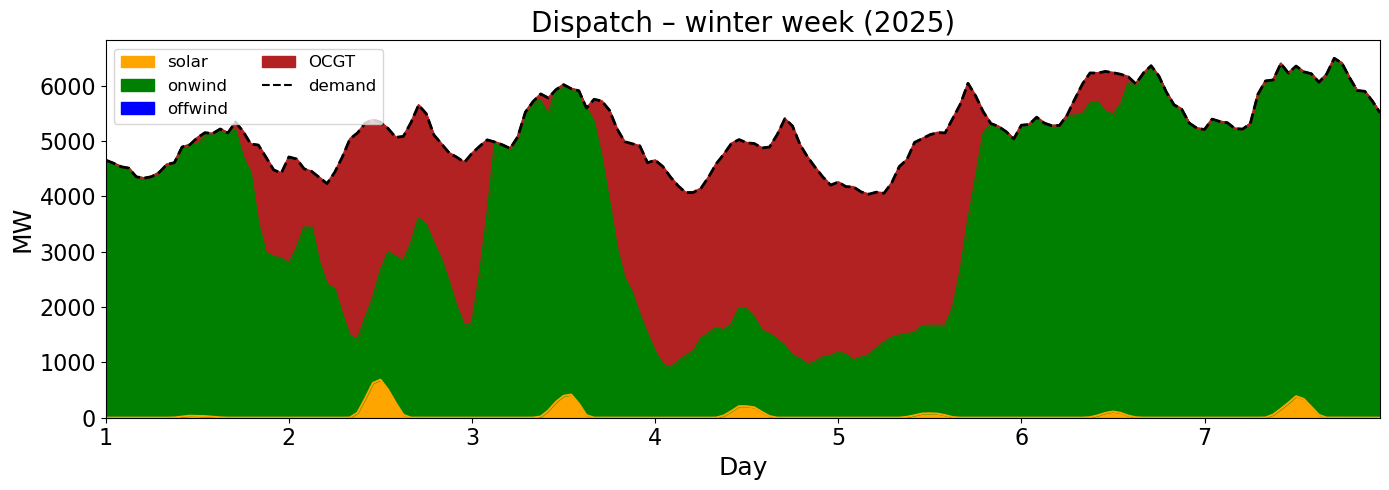

In [16]:
# @title Winter week dispatch

plot_dispatch(winter_dispatch, demand_series.loc[winter_dispatch.index], f"Dispatch – winter week ({year})")

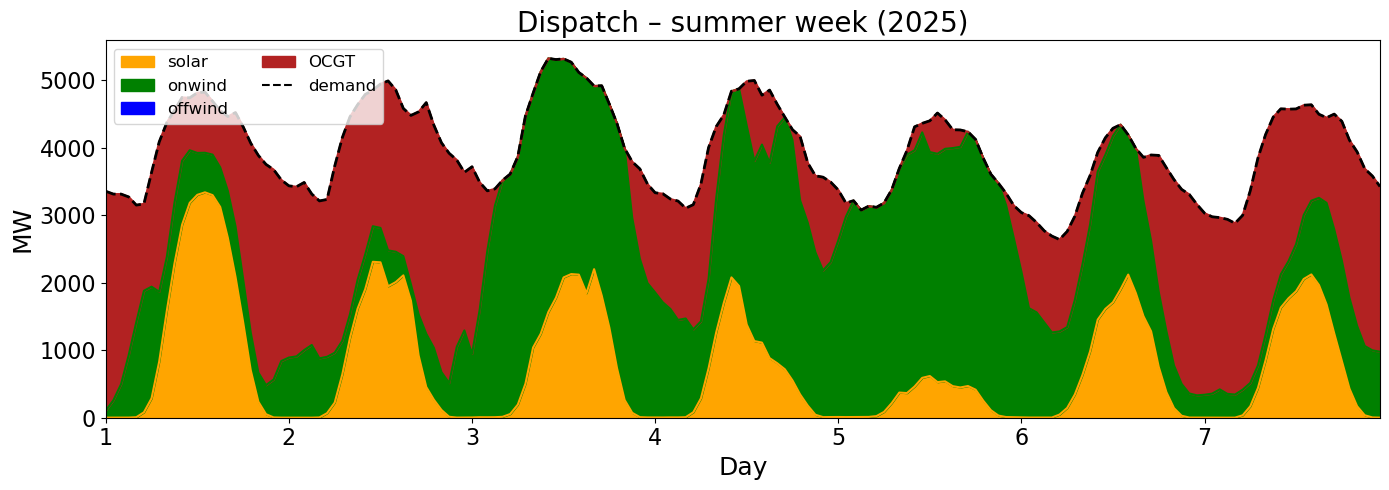

In [17]:
# @title Summer week dispatch

plot_dispatch(summer_dispatch, demand_series.loc[summer_dispatch.index], f"Dispatch – summer week ({year})")

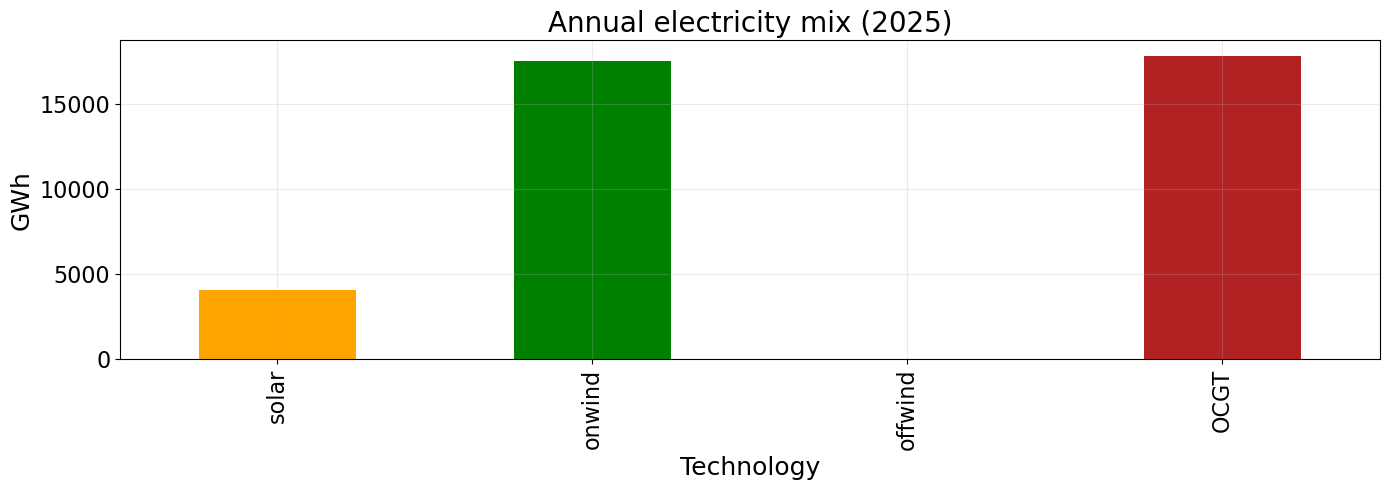

In [18]:
# @title Annual electricity mix

tech_order = ["solar", "onwind", "offwind", "OCGT"]
tech_order = [t for t in tech_order if t in annual_generation.index]

annual_generation_plot = annual_generation.reindex(tech_order).fillna(0)
mix_colors = [colors.get(col, "gray") for col in annual_generation_plot.index]

fig, ax = plt.subplots(figsize=(14, 5))
annual_generation_plot.plot(kind="bar", ax=ax, color=mix_colors)

ax.set_ylabel("GWh", fontsize=LABEL_SIZE)
ax.set_xlabel("Technology", fontsize=LABEL_SIZE)
ax.set_title(f"Annual electricity mix ({year})", fontsize=TITLE_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(True, alpha=GRID_ALPHA)

plt.tight_layout()
plt.show()

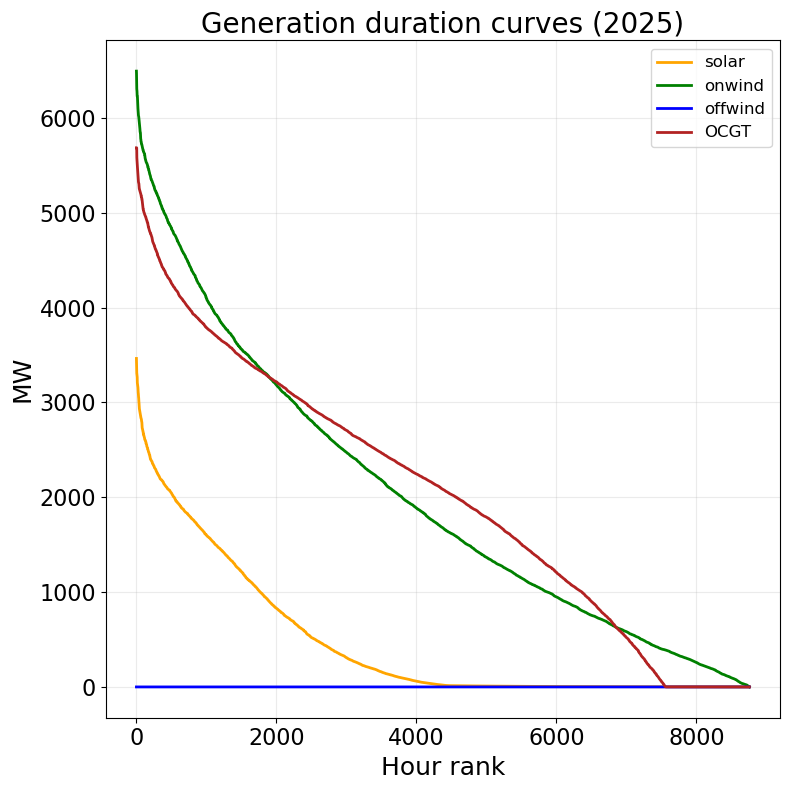

In [19]:
# @title Duration curve

tech_order = ["solar", "onwind", "offwind", "OCGT"]
tech_order = [t for t in tech_order if t in dispatch_plot.columns]

fig, ax = plt.subplots(figsize=(8, 8))

for col in tech_order:
    sorted_values = dispatch_plot[col].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(
        sorted_values.index,
        sorted_values.values,
        label=col,
        color=colors.get(col, "gray"),
        linewidth=2
    )


ax.set_xlabel("Hour rank", fontsize=LABEL_SIZE)
ax.set_ylabel("MW", fontsize=LABEL_SIZE)
ax.set_title(f"Generation duration curves ({year})", fontsize=TITLE_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.show()

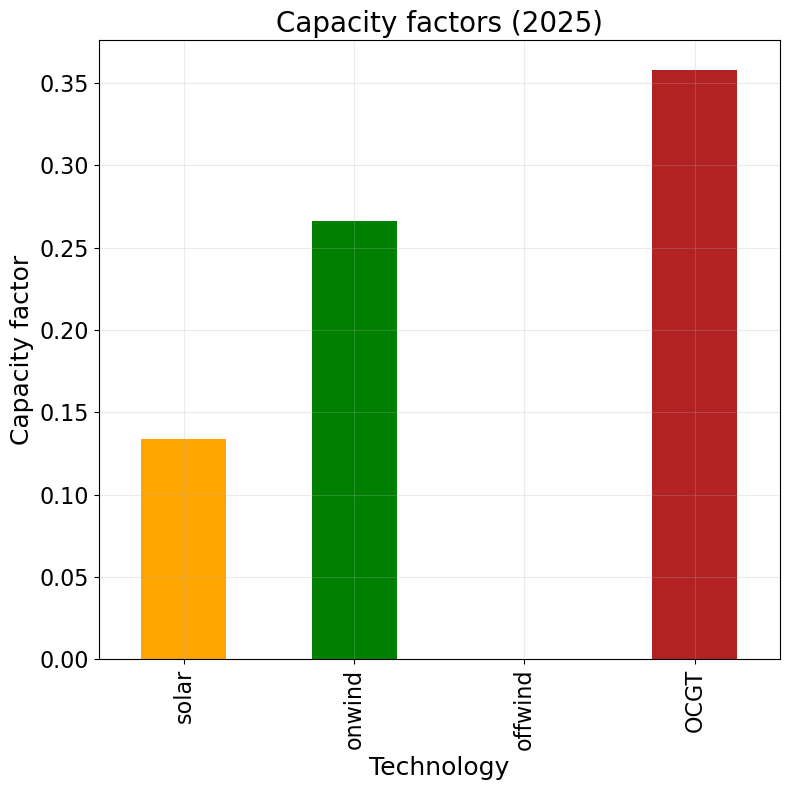

In [20]:
# @title Capacity factor chart

fig, ax = plt.subplots(figsize=(8, 8))

cf_colors = [colors.get(col, "gray") for col in capacity_factors.index]
capacity_factors.plot(kind="bar", ax=ax, color=cf_colors)

ax.set_ylabel("Capacity factor", fontsize=LABEL_SIZE)
ax.set_xlabel("Technology", fontsize=LABEL_SIZE)
ax.set_title(f"Capacity factors ({year})", fontsize=TITLE_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(True, alpha=GRID_ALPHA)

plt.tight_layout()
plt.show()

## Part B

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

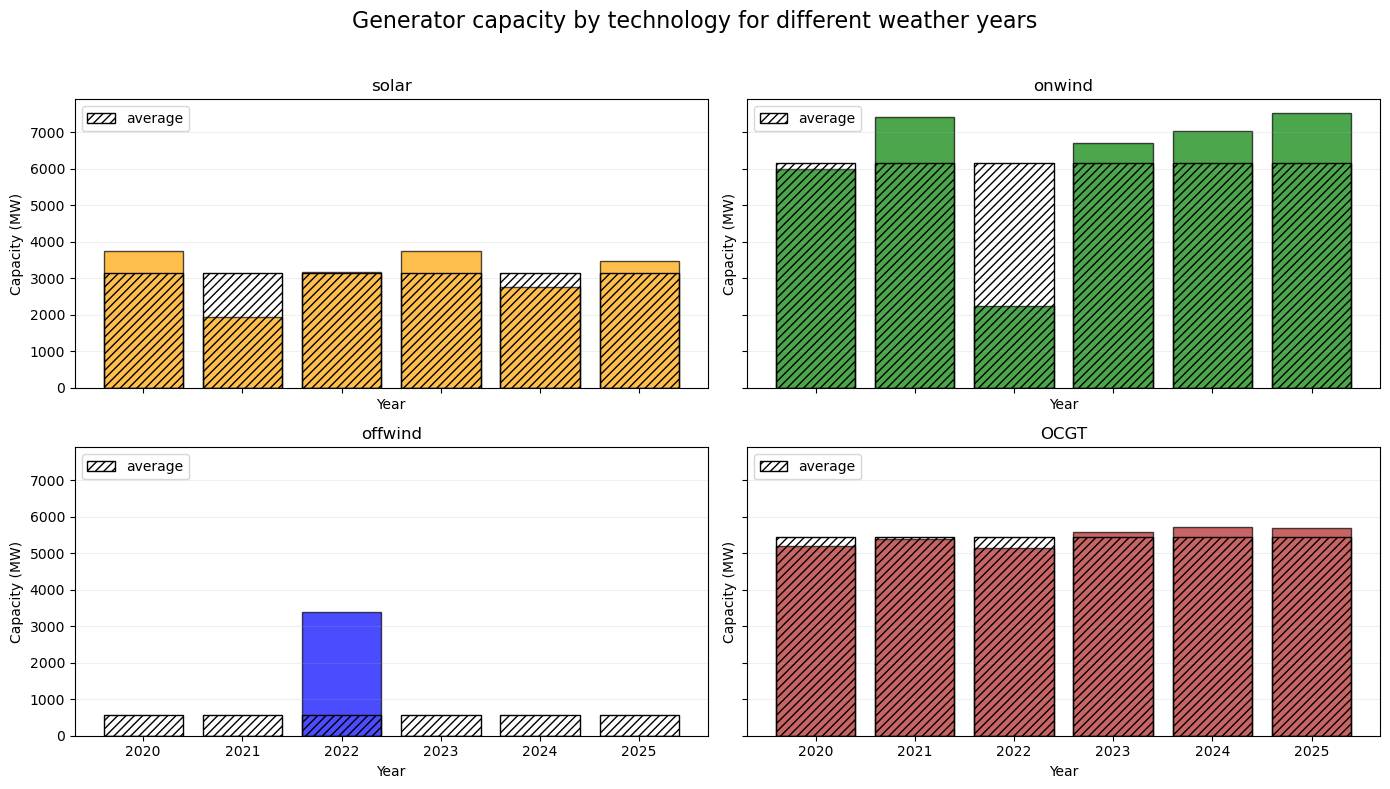

In [21]:

capacity_df = pd.DataFrame({
    year: n.generators.p_nom_opt
    for year, n in partB.items()
}).T

avg_capacity = capacity_df.mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for ax, tech in zip(axes.flat, capacity_df.columns):
    tech_values = capacity_df[tech]
    ax.bar(
        tech_values.index.astype(str),
        tech_values.values,
        color=colors.get(tech, "grey"),
        edgecolor="black",
        alpha=0.7,
    )
    ax.bar(
        tech_values.index.astype(str),
        [tech_values.mean()] * len(tech_values),
        color="none",
        edgecolor="black",
        hatch="////",
        linewidth=1.0,
        alpha=1.0,
        zorder=4,
    )
    ax.set_title(f"{tech}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Capacity (MW)")
    ax.grid(alpha=0.2, axis="y")
    avg_patch = Patch(facecolor="none", edgecolor="black", hatch="////", label="average")
    ax.legend(handles=[avg_patch], loc="upper left")

fig.suptitle("Generator capacity by technology for different weather years", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


# 2nd Model Building (Storage Added)

In [22]:
# @title Building a new instance of the 1st network

# Rebuild a fresh network object for model 2 to avoid state carried from model 1 optimization.

cf_year_2 = cf[cf.index.year == tech_year].copy()
cf_year_2["solar"] /= cf_year_2["solar"].max()
cf_year_2["onwind"] /= cf_year_2["onwind"].max()
cf_year_2["offwind"] /= cf_year_2["offwind"].max()

n2 = pypsa.Network()
n2.set_snapshots(cf_year_2.index)

for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "load_shedding"]:
    n2.add("Carrier", carrier)

n2.add("Bus", "electricity", carrier="electricity")
n2.add("Load", "demand", bus="electricity", p_set=cf_year_2["demand"])

n2.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_nom_extendable=True,
    p_max_pu=cf_year_2["solar"],
    capital_cost=costs.at["solar", "capital_cost"],
    marginal_cost=costs.at["solar", "marginal_cost"],
)

n2.add(
    "Generator",
    "onwind",
    bus="electricity",
    carrier="onwind",
    p_nom_extendable=True,
    p_max_pu=cf_year_2["onwind"],
    capital_cost=costs.at["onwind", "capital_cost"],
    marginal_cost=costs.at["onwind", "marginal_cost"],
)

n2.add(
    "Generator",
    "offwind",
    bus="electricity",
    carrier="offwind",
    p_nom_extendable=True,
    p_max_pu=cf_year_2["offwind"],
    capital_cost=costs.at["offwind", "capital_cost"],
    marginal_cost=costs.at["offwind", "marginal_cost"],
)

n2.add(
    "Generator",
    "OCGT",
    bus="electricity",
    carrier="gas",
    p_nom_extendable=True,
    #p_nom_max = 2000,  # [MW] let's try limiting it
    capital_cost=costs.at["OCGT", "capital_cost"],
    efficiency = costs.at["OCGT", "efficiency"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
)

n2.add(
    "Generator",
    "load_shedding",
    bus="electricity",
    carrier="load_shedding",
    p_nom=float(cf_year_2["demand"].max()),
    marginal_cost=10_000,
)

In [23]:
# @title Adding battery storage components

bicharger_tech = "Lithium-Ion-NMC-bicharger"
storage_tech = "Lithium-Ion-NMC-store"

# --- Parameters ---

# Power component
inv_p = costs.at[bicharger_tech, "investment"]
fom_p = costs.at[bicharger_tech, "FOM"]
life_p = costs.at[bicharger_tech, "lifetime"]
capital_cost_p = costs.at[bicharger_tech, "capital_cost"]
vom_p = costs.at[bicharger_tech, "VOM"]

# Energy component
inv_e = costs.at[storage_tech, "investment"]
fom_e = costs.at[storage_tech, "FOM"]
life_e = costs.at[storage_tech, "lifetime"]

capital_cost_e = costs.at[storage_tech, "capital_cost"]

# Efficiency
eta = costs.at[bicharger_tech, "efficiency"]

# --- Model ---

n2.add("Carrier", "battery")
n2.add("Bus", "battery", carrier="battery", overwrite=True)


# Energy storage
n2.add("Store",
      "battery_store",
      bus="battery",
      e_nom_extendable=True,
      #e_nom_extendable=False,
      #e_nom = 500,             # [MWh] forced capcity
      capital_cost=capital_cost_e,
      e_cyclic=True,
      overwrite=True)

# Bidirectional power link
n2.add("Link",
      "battery_link",
      bus0="electricity",
      bus1="battery",
      p_nom_extendable=True,
      #p_nom_extendable=False,
      #p_nom=100,              # [MW] Forcing it in for debugging


      efficiency=eta,          # electricity → battery
      efficiency2=eta,         # battery → electricity

      #efficiency=0.99,          # electricity → battery
      #efficiency2=0.99,         # battery → electricity

      capital_cost=capital_cost_p,
      marginal_cost=vom_p,

      p_min_pu=-1,             # discharging to grid
      p_max_pu=1,              # charging battery
      overwrite=True)

In [24]:
# @title Adding H-bus and H components

n2.add("Bus", "hydrogen", carrier="hydrogen", overwrite=True)

n2.add("Carrier", "hydrogen", overwrite=True)

#---------------
# Electricity -> Hydrogen (Proton Exchange Membrane electrolyzer)
#--------------

tech = "PEM electrolyzer"

r = costs.at[tech, "discount rate"]
inv = costs.at[tech, "investment"]
fom = costs.at[tech, "FOM"]
life = costs.at[tech, "lifetime"]
eta = costs.at[tech, "efficiency"]
capital_cost_electrolyser = costs.at["PEM electrolyzer", "capital_cost"]
vom_electrolyser = costs.at["PEM electrolyzer", "VOM"]

n2.add("Link",
      "electrolyser",
      bus0="electricity",
      bus1="hydrogen",
      p_nom_extendable=True,
      efficiency=eta*0.95, # Compression + auxiliaries efficiency losses
      #efficiency=0.99,
      capital_cost=capital_cost_electrolyser,
      marginal_cost=vom_electrolyser,
      overwrite=True,
      p_min_pu=0) # Min power flow is 0 and not negative:
      # we want to restrict H energy being converted into electrical energy here
      # as the electrolizer is monodirectional energy converter.

#----------------
# Hydrogen storage
#---------------

tech = "hydrogen storage underground"

r = costs.at[tech, "discount rate"]
inv = costs.at[tech, "investment"]
fom = costs.at[tech, "FOM"]
life = costs.at[tech, "lifetime"]
capital_cost_h2 = costs.at["hydrogen storage underground", "capital_cost"]

n2.add("Store",
      "hydrogen_storage",
      bus="hydrogen",
      e_nom_extendable=True,
      capital_cost=capital_cost_h2,
      e_cyclic=True,
      standing_loss=0.0,
      overwrite=True)

#-----------------
# Hydrogen -> Electricity (Open cycle gas turbine running on H)
#-----------------

tech = "OCGT"  # Same technology, just runs on hydrogen now

r = costs.at[tech, "discount rate"]
inv = costs.at[tech, "investment"]
fom = costs.at[tech, "FOM"]
life = costs.at[tech, "lifetime"]
eta = costs.at[tech, "efficiency"]
capital_cost_h2_turbine = costs.at["OCGT", "capital_cost"]
vom_h2_turbine = costs.at["OCGT", "VOM"]

n2.add("Link",
      "hydrogen_turbine",
      bus0="hydrogen",
      bus1="electricity",
      p_nom_extendable=True,
      efficiency=eta,
      # efficiency=0.99,
      capital_cost=capital_cost_h2_turbine,
      marginal_cost=vom_h2_turbine,
      overwrite=True,
      p_min_pu=0) # Min power flow is 0 and not negative:
      # we want to restrict electrical energy being converted into H here
      # as the gas turbine is monodirectional energy converter.

In [25]:
display(costs.loc[["Lithium-Ion-NMC-bicharger", "Lithium-Ion-NMC-store", "PEM electrolyzer", "hydrogen storage underground", "OCGT"], ["capital_cost", "marginal_cost", "efficiency", "lifetime"]])

parameter,capital_cost,marginal_cost,efficiency,lifetime
technology,,,,
Lithium-Ion-NMC-bicharger,12452.853769,0.000000,0.9193,13.0
Lithium-Ion-NMC-store,38510.906852,0.000000,1.0000,13.0
PEM electrolyzer,89767.232832,0.000000,0.6550,30.0
hydrogen storage underground,185.405671,0.000000,1.0000,100.0
OCGT,48739.697513,65.423728,0.4050,25.0


# 2nd Model Optimisation

In [26]:
co2 = copy.deepcopy(n2)
conwind = copy.deepcopy(n2)
n2.optimize(solver_name="highs")

C:\Users\marm\AppData\Local\Temp\ipykernel_11824\874928987.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n2.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 7/7 [00:00<00:00, 400.52it/s]
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105117 primals, 218984 duals
Objective: 2.50e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lo

('ok', 'optimal')

## 2nd Model Results Preparation

In [27]:
# @title Extracting different dispatches

# Exclude load shedding
dispatch = n2.generators_t.p.copy()

battery_dispatch = -1*n2.links_t.p1["battery_link"].clip(upper=0).copy()
# H_dispatch = -n2.links_t.p1["hydrogen_turbine"].copy()
H_dispatch = n2.links_t.p1["hydrogen_turbine"].clip(lower=0).copy()

# Exclude load shedding
# dispatch_clean = dispatch.drop(columns="load_shedding", errors="ignore")

In [28]:
# @title Calculating common dispatch

# Adding battery and H turbine to the dispatch
common_dispatch = dispatch.copy()
common_dispatch["battery"] = battery_dispatch.round().abs()
common_dispatch["H-turbine"] = H_dispatch

# Creating summer and winter dataframes
common_dispatch_winter = common_dispatch.loc[winter_week_start:winter_week_end]
common_dispatch_summer = common_dispatch.loc[summer_week_start:summer_week_end]

In [29]:
# @title Calculating state of charge [%]

soc = n2.stores_t.e["battery_store"]
# e_nom = n2.stores.e["battery_store"] * n2.stores.max_hours["battery_store"]

soc_percent = 100 * soc

In [30]:
# @title Calcualting annual generation

annual_generation = (common_dispatch.sum() / 1000).round(2)

In [31]:
# @title Calculating capacities and capacity factors

gen_capacities = n2.generators["p_nom_opt"].drop("load_shedding", errors="ignore")

storage_capacities = n2.links["p_nom_opt"]

common_capacities = gen_capacities.copy()
common_capacities["battery_link"] = storage_capacities["battery_link"]
common_capacities["hydrogen_turbine"] = storage_capacities["hydrogen_turbine"]

capacity_factors = (
    common_dispatch.sum() / (common_capacities * len(n2.snapshots))
).fillna(0).round(3)

In [32]:
# @title Calculating annual revenues

# Get the momentary generation of each generator
generator_generation = n2.generators_t.p

# Get the electricity prices (assuming 'electricity_prices' was defined previously)
# If not, uncomment the following line to re-define it:
electricity_prices = n2.buses_t.marginal_price["electricity"]

# Multiply momentary generation by electricity price to get momentary revenue
momentary_generation_revenue = generator_generation.mul(electricity_prices, axis=0)

# Sum the momentary generation revenue over all timesteps (rows) to get the annual revenue for each generator
annual_generation_revenue = momentary_generation_revenue.sum()/1e6 # M€

## 2nd Model Results Plotting

In [33]:
# @title Numerical Values

print("Optimal capacities (MW)")
display(common_capacities.round(2))

print("\nAnnual generation (GWh)")
display(annual_generation)

print("\nCapacity factors")
display(capacity_factors)

print("\nAnnual Generation Revenue for each generator:")
display(annual_generation_revenue)
print(f"TOTAL cost for consumer: {round(annual_generation_revenue.sum(),2)} M€.")

Optimal capacities (MW)


name
solar               3463.75
onwind              7529.51
offwind               -0.00
OCGT                5685.41
battery_link          -0.00
hydrogen_turbine      -0.00
Name: p_nom_opt, dtype: float64


Annual generation (GWh)


name
solar             4078.45
onwind           17540.18
offwind              0.00
OCGT             17847.65
load_shedding        0.41
battery              0.00
H-turbine            0.00
dtype: float64


Capacity factors


name
H-turbine           0.000
OCGT                0.358
battery             0.000
battery_link        0.000
hydrogen_turbine    0.000
load_shedding       0.000
offwind             0.000
onwind              0.266
solar               0.134
dtype: float64


Annual Generation Revenue for each generator:


name
solar             218.657353
onwind            835.432195
offwind             0.000000
OCGT             1444.765454
load_shedding       4.062626
dtype: float64

TOTAL cost for consumer: 2502.92 M€.


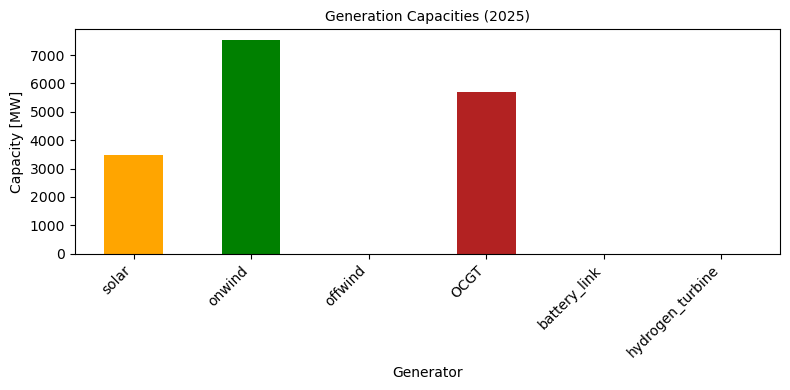

In [34]:
# @title Capacities visualisation
fig, ax = plt.subplots(figsize=(8, 4))

common_capacities.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in gen_capacities.index])
#storage_capacities.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in storage_capacities.index])

ax.set_ylabel("Capacity [MW]", size=10)
ax.set_xlabel("Generator", size=10)
ax.set_title(f"Generation Capacities ({common_dispatch.index.year.min()})", size=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

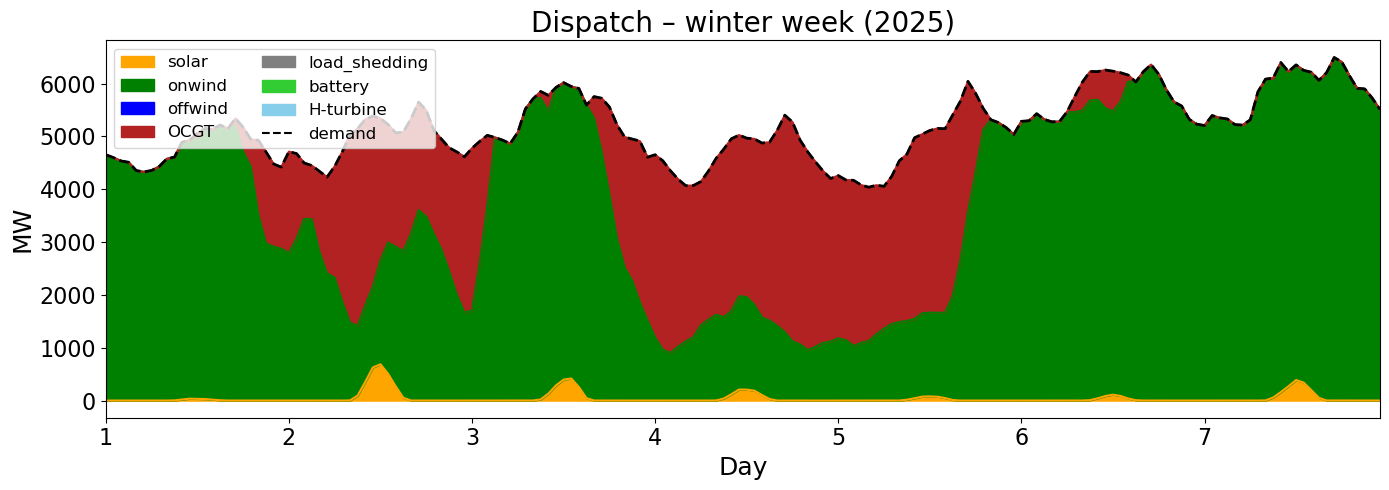

In [35]:
# @title Winter week dispatches
plot_dispatch(common_dispatch_winter, demand_series_winter, f"Dispatch – winter week ({common_dispatch.index.year.min()})")

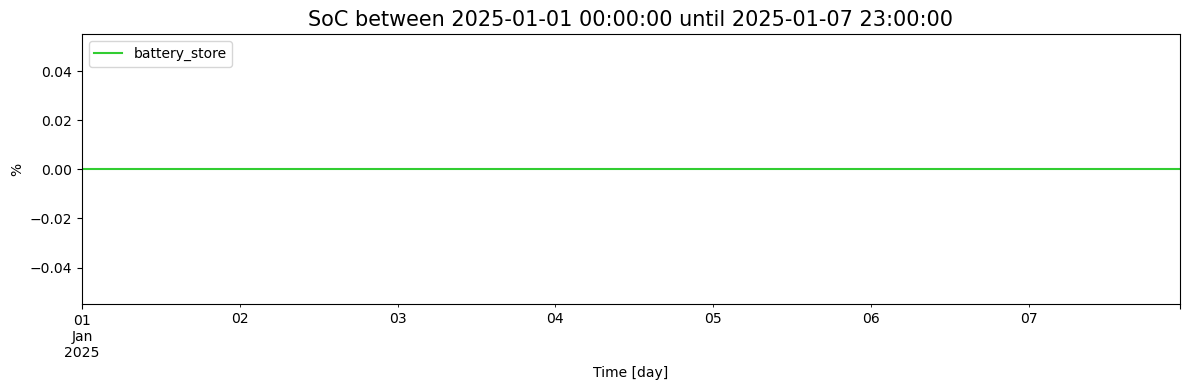

In [36]:
# @title Winter week SoC
plot_SoC(soc_percent.loc[winter_week_start:winter_week_end], "day")

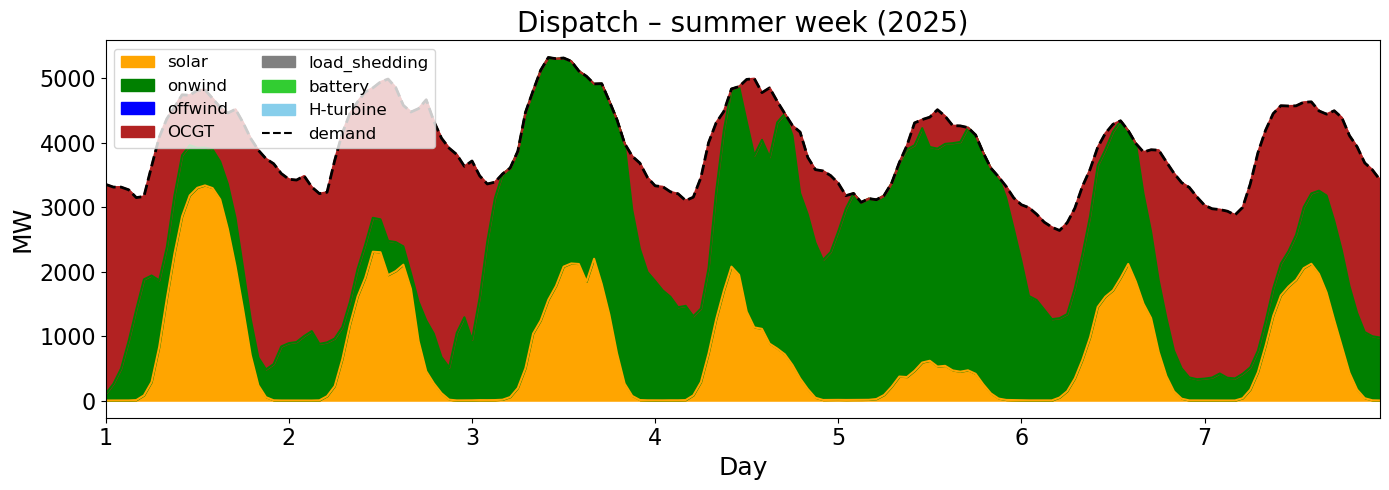

In [37]:
# @title Summer week dispatches
plot_dispatch(common_dispatch_summer, demand_series_summer, f"Dispatch – summer week ({common_dispatch.index.year.min()})")

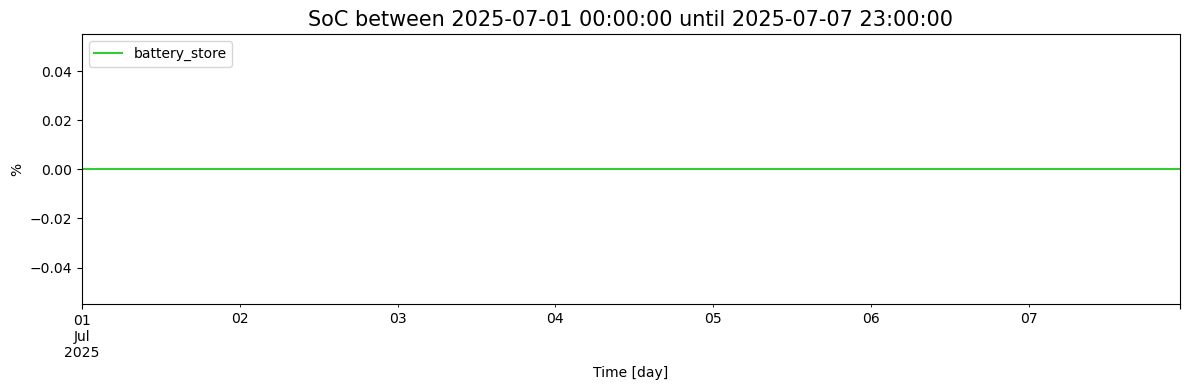

In [38]:
# @title Summer week SoC
plot_SoC(soc_percent.loc[summer_week_start:summer_week_end], "day")

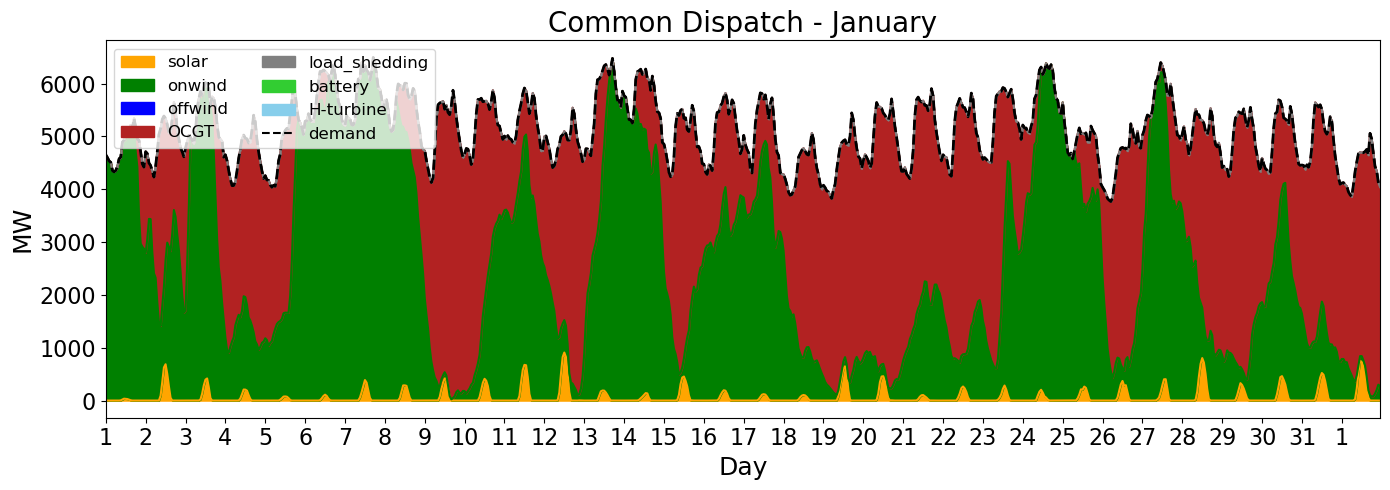

In [39]:
# @title Common Disptach - January
month_start = f"{common_dispatch.index.year.min()}-01-01"
month_end = f"{common_dispatch.index.year.min()}-02-01"

plot_dispatch(
    common_dispatch.loc[month_start:month_end],
    demand_series.loc[month_start:month_end],
    "Common Dispatch - January"
)

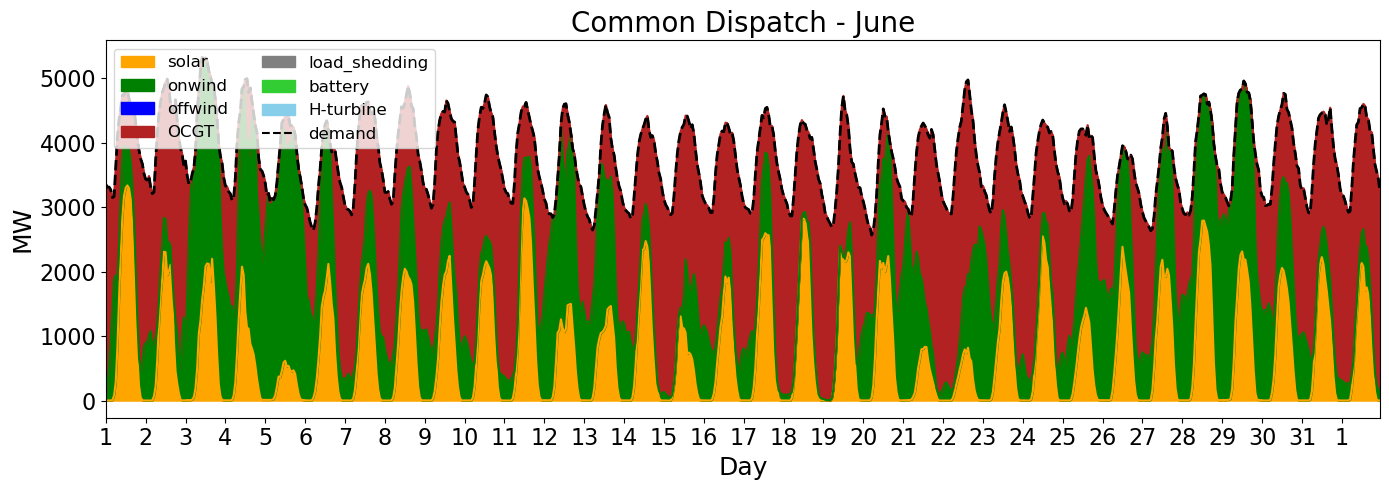

In [40]:
# @title Common Disptach - June
# @title Common Dispatch - June
month_start = f"{common_dispatch.index.year.min()}-07-01"
month_end = f"{common_dispatch.index.year.min()}-08-01"

plot_dispatch(
    common_dispatch.loc[month_start:month_end],
    demand_series.loc[month_start:month_end],
    "Common Dispatch - June"
)

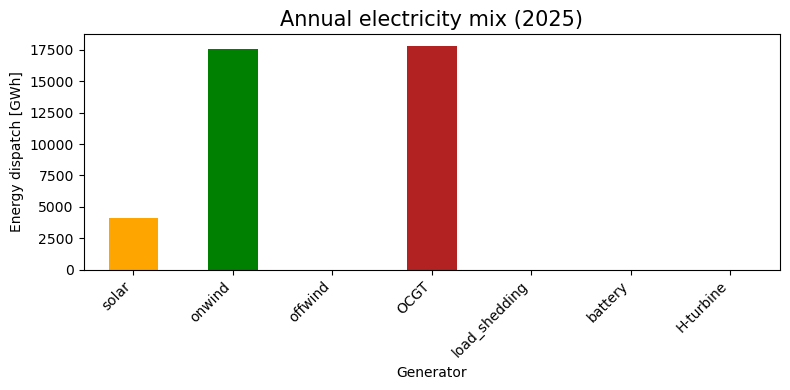

In [41]:
# @title New annual electricity mix

plot_electricity_mix(common_dispatch)

In [42]:
'''
Optional snippet to analyse the change inoptimal battery and H electrolyzer capacities when
OCGT introducing various OCGT capacity limits.

NB! Runtime may exceed 5 min
'''

def ocgtLimitComp():

    for cap in [1000, 2000, 3000, 4000, cf_year_2["demand"].max()]:
        n2.generators.at["OCGT", "p_nom_max"] = cap
        n2.optimize(solver_name="highs")
        bat = n2.links.at["battery_link", "p_nom_opt"]
        h2  = n2.links.at["electrolyser", "p_nom_opt"]
        print("################")
        print(f"OCGT cap {cap} MW → battery {bat:.0f} MW, H2 electrolyser {h2:.0f} MW")
        print("################")


# ocgtLimitComp() # uncomment to run

# 3rd Model Building (Connecting to Neighbouring Countries)

## Data import and handling

In [45]:
#Data import and handling (OPSD only, 2019)

task_d_year = 2019

# opsd = pd.read_csv("time_series_60min_singleindex.csv")
opsd = pd.read_csv("C:/Users/marm/OneDrive - Gomspace/Documents/Admin docs/School/Integrated grids/Python Environment/Project/Data/time_series_60min_singleindex.csv")
opsd["utc_timestamp"] = pd.to_datetime(opsd["utc_timestamp"], utc=True)
opsd = opsd.set_index("utc_timestamp")

opsd_y = opsd[opsd.index.year == task_d_year].copy()

# Hourly demand
demand = pd.DataFrame(index=opsd_y.index)

demand["DK1"] = opsd_y["DK_1_load_actual_entsoe_transparency"].fillna(0.0)
demand["DK2"] = opsd_y["DK_2_load_actual_entsoe_transparency"].fillna(0.0)
demand["DE"]  = opsd_y["DE_load_actual_entsoe_transparency"].fillna(0.0)
demand["SE"]  = opsd_y["SE_load_actual_entsoe_transparency"].fillna(0.0)
demand["NO"]  = opsd_y["NO_load_actual_entsoe_transparency"].fillna(0.0)

# Renewable availability factors
# generation / yearly max generation
cf_d = pd.DataFrame(index=opsd_y.index)

for area in ["DK1", "DK2"]:
    prefix = "DK_1" if area == "DK1" else "DK_2"

    cf_d[f"{area}_solar"] = (
        opsd_y[f"{prefix}_solar_generation_actual"]
        / opsd_y[f"{prefix}_solar_generation_actual"].max()
    ).fillna(0.0)

    cf_d[f"{area}_onwind"] = (
        opsd_y[f"{prefix}_wind_onshore_generation_actual"]
        / opsd_y[f"{prefix}_wind_onshore_generation_actual"].max()
    ).fillna(0.0)

    cf_d[f"{area}_offwind"] = (
        opsd_y[f"{prefix}_wind_offshore_generation_actual"]
        / opsd_y[f"{prefix}_wind_offshore_generation_actual"].max()
    ).fillna(0.0)

# Fixed neighbour capacities [MW]
# Use OPSD capacities where available
def last_valid(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.iloc[-1]) if len(s) > 0 else 0.0

neighbor_caps = pd.DataFrame(index=["DE", "SE", "NO"], columns=["solar", "onwind", "offwind", "ocgt"], dtype=float)

# Germany: capacities exist directly in OPSD
neighbor_caps.loc["DE", "solar"]   = last_valid(opsd_y["DE_solar_capacity"])
neighbor_caps.loc["DE", "onwind"]  = last_valid(opsd_y["DE_wind_onshore_capacity"])
neighbor_caps.loc["DE", "offwind"] = last_valid(opsd_y["DE_wind_offshore_capacity"])

# Sweden: only onshore/offshore wind capacities exist, but we only have onshore generation
neighbor_caps.loc["SE", "solar"]   = 0.0
neighbor_caps.loc["SE", "onwind"]  = last_valid(opsd_y["SE_wind_onshore_capacity"])
neighbor_caps.loc["SE", "offwind"] = 0.0

# Norway: no clean OPSD capacity column in this file, so use max observed generation as proxy
neighbor_caps.loc["NO", "solar"]   = 0.0
neighbor_caps.loc["NO", "onwind"]  = opsd_y["NO_wind_onshore_generation_actual"].max()
neighbor_caps.loc["NO", "offwind"] = 0.0


# Neighbour renewable availability factors

# Germany: use OPSD profile columns directly
cf_d["DE_solar"]   = pd.to_numeric(opsd_y["DE_solar_profile"], errors="coerce").fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["DE_onwind"]  = pd.to_numeric(opsd_y["DE_wind_onshore_profile"], errors="coerce").fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["DE_offwind"] = pd.to_numeric(opsd_y["DE_wind_offshore_profile"], errors="coerce").fillna(0.0).clip(lower=0.0, upper=1.0)

# Sweden: use actual generation / installed capacity
cf_d["SE_solar"] = 0.0
cf_d["SE_onwind"] = (
    opsd_y["SE_wind_onshore_generation_actual"] / neighbor_caps.loc["SE", "onwind"]
).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["SE_offwind"] = 0.0

# Norway: use actual generation / proxy capacity
cf_d["NO_solar"] = 0.0
cf_d["NO_onwind"] = (
    opsd_y["NO_wind_onshore_generation_actual"] / neighbor_caps.loc["NO", "onwind"]
).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["NO_offwind"] = 0.0

cf_d = cf_d.fillna(0.0)

# Fixed neighbour OCGT capacities [MW]
actual_gen = pd.DataFrame(index=opsd_y.index)

actual_gen["DE_solar"]   = opsd_y["DE_solar_generation_actual"].fillna(0.0)
actual_gen["DE_onwind"]  = opsd_y["DE_wind_onshore_generation_actual"].fillna(0.0)
actual_gen["DE_offwind"] = opsd_y["DE_wind_offshore_generation_actual"].fillna(0.0)

actual_gen["SE_solar"]   = 0.0
actual_gen["SE_onwind"]  = opsd_y["SE_wind_onshore_generation_actual"].fillna(0.0)
actual_gen["SE_offwind"] = 0.0

actual_gen["NO_solar"]   = 0.0
actual_gen["NO_onwind"]  = opsd_y["NO_wind_onshore_generation_actual"].fillna(0.0)
actual_gen["NO_offwind"] = 0.0

for area in ["DE", "SE", "NO"]:
    residual = (
        demand[area]
        - actual_gen[f"{area}_solar"]
        - actual_gen[f"{area}_onwind"]
        - actual_gen[f"{area}_offwind"]
    ).clip(lower=0.0)
    neighbor_caps.loc[area, "ocgt"] = residual.max()

neighbor_caps = neighbor_caps.fillna(0.0)


# Fixed line capacities [MW]
# Existing interconnector transfer capacities
line_data = pd.DataFrame([
    ["DK1", "DK2",  590],
    ["DK1", "DE", 2500],
    ["DK2", "DE",  585],
    ["DK2", "SE", 1300],
    ["DK1", "NO", 1632],
], columns=["bus0", "bus1", "s_nom"])

line_data["x"] = 0.1
line_data["v_nom"] = 400

print("Task d year:", task_d_year)
print("Snapshots:", len(opsd_y))
display(demand.head())
display(cf_d.head())
display(neighbor_caps.round(2))
display(line_data)

Task d year: 2019
Snapshots: 8760


,DK1,DK2,DE,SE,NO
utc_timestamp,,,,,
2019-01-01 00:00:00+00:00,1837.71,1348.33,41562.0,14375.0,15622.94
2019-01-01 01:00:00+00:00,1778.86,1291.21,40100.0,14153.0,15705.29
2019-01-01 02:00:00+00:00,1726.38,1239.81,38883.0,13896.0,15643.08
2019-01-01 03:00:00+00:00,1709.62,1223.86,38806.0,13955.0,15611.87
2019-01-01 04:00:00+00:00,1716.39,1224.25,38593.0,14166.0,15727.78


,DK1_solar,DK1_onwind,DK1_offwind,DK2_solar,DK2_onwind,DK2_offwind,DE_solar,DE_onwind,DE_offwind,SE_solar,SE_onwind,SE_offwind,NO_solar,NO_onwind,NO_offwind
utc_timestamp,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.0,0.726043,0.209534,0.0,0.898586,0.903388,0.0,0.5017,0.5678,0.0,0.595856,0.0,0.0,0.490911,0.0
2019-01-01 01:00:00+00:00,0.0,0.692453,0.090343,0.0,0.819642,0.720862,0.0,0.5179,0.4870,0.0,0.570469,0.0,0.0,0.498384,0.0
2019-01-01 02:00:00+00:00,0.0,0.685225,0.088387,0.0,0.794851,0.566904,0.0,0.5435,0.5341,0.0,0.561703,0.0,0.0,0.487684,0.0
2019-01-01 03:00:00+00:00,0.0,0.666757,0.086499,0.0,0.764962,0.552355,0.0,0.5902,0.5105,0.0,0.557263,0.0,0.0,0.463944,0.0
2019-01-01 04:00:00+00:00,0.0,0.645172,0.086212,0.0,0.758067,0.552222,0.0,0.6244,0.4710,0.0,0.557149,0.0,0.0,0.449288,0.0


,solar,onwind,offwind,ocgt
DE,50508.0,44710.00,5742.0,72655.00
SE,0.0,8784.00,0.0,24402.00
NO,0.0,1936.44,0.0,26934.46


,bus0,bus1,s_nom,x,v_nom
0,DK1,DK2,590,0.1,400
1,DK1,DE,2500,0.1,400
2,DK2,DE,585,0.1,400
3,DK2,SE,1300,0.1,400
4,DK1,NO,1632,0.1,400


## Building network

In [46]:
# PyPSA requires timezone-naive snapshots; align all related time series.
snapshots_3 = opsd_y.index.tz_localize(None)
demand_3 = demand.copy()
cf_d_3 = cf_d.copy()
demand_3.index = snapshots_3
cf_d_3.index = snapshots_3

n3 = pypsa.Network()
n3.set_snapshots(snapshots_3)

# -----------------------------
# Carriers
# -----------------------------
for carrier in ["AC", "solar", "onwind", "offwind", "gas", "load_shedding", "hydrogen"]:
    n3.add("Carrier", carrier)

# -----------------------------
# Buses
# -----------------------------
for bus in ["DK1", "DK2", "DE", "SE", "NO"]:
    n3.add("Bus", bus, carrier="AC", v_nom=400)

n3.add("Bus", "DK1_hydrogen", carrier="hydrogen")
n3.add("Bus", "DK2_hydrogen", carrier="hydrogen")

# -----------------------------
# Loads
# -----------------------------
for bus in ["DK1", "DK2", "DE", "SE", "NO"]:
    n3.add("Load", f"{bus}_demand", bus=bus, p_set=demand_3[bus])

# -----------------------------
# Danish extendable generators
# -----------------------------
for bus in ["DK1", "DK2"]:
    n3.add(
        "Generator",
        f"{bus}_solar",
        bus=bus,
        carrier="solar",
        p_nom_extendable=True,
        p_max_pu=cf_d_3[f"{bus}_solar"],
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_onwind",
        bus=bus,
        carrier="onwind",
        p_nom_extendable=True,
        p_max_pu=cf_d_3[f"{bus}_onwind"],
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_offwind",
        bus=bus,
        carrier="offwind",
        p_nom_extendable=True,
        p_max_pu=cf_d_3[f"{bus}_offwind"],
        capital_cost=costs.at["offwind", "capital_cost"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_OCGT",
        bus=bus,
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_load_shedding",
        bus=bus,
        carrier="load_shedding",
        p_nom=float(demand_3[bus].max()),
        marginal_cost=10000,
    )

# -----------------------------
# Fixed neighbour generators
# -----------------------------
for bus in ["DE", "SE", "NO"]:
    n3.add(
        "Generator",
        f"{bus}_solar",
        bus=bus,
        carrier="solar",
        p_nom=neighbor_caps.loc[bus, "solar"],
        p_max_pu=cf_d_3[f"{bus}_solar"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_onwind",
        bus=bus,
        carrier="onwind",
        p_nom=neighbor_caps.loc[bus, "onwind"],
        p_max_pu=cf_d_3[f"{bus}_onwind"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_offwind",
        bus=bus,
        carrier="offwind",
        p_nom=neighbor_caps.loc[bus, "offwind"],
        p_max_pu=cf_d_3[f"{bus}_offwind"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_OCGT",
        bus=bus,
        carrier="gas",
        p_nom=neighbor_caps.loc[bus, "ocgt"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

# -----------------------------
# Danish battery storage
# -----------------------------
for bus in ["DK1", "DK2"]:
    n3.add(
        "StorageUnit",
        f"{bus}_battery",
        bus=bus,
        p_nom_extendable=True,
        max_hours=4,
        capital_cost=(
            costs.at["Lithium-Ion-NMC-bicharger", "capital_cost"]
            + costs.at["Lithium-Ion-NMC-store", "capital_cost"]
        ),
        marginal_cost=costs.at["Lithium-Ion-NMC-bicharger", "marginal_cost"],
        efficiency_store=0.95,
        efficiency_dispatch=0.95,
        cyclic_state_of_charge=True,
    )


# Danish hydrogen components
for bus in ["DK1", "DK2"]:
    h2_bus = f"{bus}_hydrogen"

    n3.add(
        "Link",
        f"{bus}_electrolyser",
        bus0=bus,
        bus1=h2_bus,
        p_nom_extendable=True,
        efficiency=0.70,
        p_min_pu=0,
        capital_cost=costs.at["PEM electrolyzer", "capital_cost"],
    )

    n3.add(
        "Store",
        f"{bus}_hydrogen_storage",
        bus=h2_bus,
        e_nom_extendable=True,
        capital_cost=costs.at["hydrogen storage underground", "capital_cost"],
        e_cyclic=True,
    )

    n3.add(
        "Link",
        f"{bus}_hydrogen_turbine",
        bus0=h2_bus,
        bus1=bus,
        p_nom_extendable=True,
        efficiency=0.50,
        p_min_pu=0,
        capital_cost=costs.at["fuel cell", "capital_cost"],
    )


# Lines
for i, row in line_data.iterrows():
    n3.add(
        "Line",
        f"{row.bus0}_{row.bus1}",
        bus0=row.bus0,
        bus1=row.bus1,
        s_nom=row.s_nom,
        x=row.x,
        r=1e-6,
    )

# 3rd Model Optimisation

In [47]:
n3.optimize(solver_name="highs", include_objective_constant=False)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████████████████████████████████████████████| 12/12 [00:00<00:00, 303.71it/s]
INFO:linopy.io: Writing time: 0.35s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 359176 primals, 788416 duals
Objective: 3.87e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance were no

('ok', 'optimal')

In [48]:
print("Optimal Danish generator capacities [MW]")
display(
    n3.generators.loc[
        [g for g in n3.generators.index if g.startswith("DK1_") or g.startswith("DK2_")],
        ["bus", "carrier", "p_nom_opt"]
    ].round(2)
)

print("Fixed neighbour capacities [MW]")
display(
    n3.generators.loc[
        [g for g in n3.generators.index if g.startswith("DE_") or g.startswith("SE_") or g.startswith("NO_")],
        ["bus", "carrier", "p_nom"]
    ].round(2)
)

print("Optimal Danish battery capacities [MW]")
display(n3.storage_units[["bus", "p_nom_opt", "max_hours"]].round(2))

print("Optimal Danish hydrogen capacities")
display(n3.links.loc[n3.links.index.str.contains("electrolyser|hydrogen_turbine"), ["bus0", "bus1", "p_nom_opt"]].round(2))
display(n3.stores[["bus", "e_nom_opt"]].round(2))

print("Fixed line capacities [MW]")
display(n3.lines[["bus0", "bus1", "s_nom"]])

print("Total load shedding [MWh]")
display(
    n3.generators_t.p[["DK1_load_shedding", "DK2_load_shedding"]].sum().round(2)
)

Optimal Danish generator capacities [MW]


,bus,carrier,p_nom_opt
name,,,
DK1_solar,DK1,solar,1111.99
DK1_onwind,DK1,onwind,8850.14
DK1_offwind,DK1,offwind,-0.00
DK1_OCGT,DK1,gas,-0.00
DK1_load_shedding,DK1,load_shedding,4952.33
DK2_solar,DK2,solar,3298.47
DK2_onwind,DK2,onwind,5261.80
DK2_offwind,DK2,offwind,-0.00
DK2_OCGT,DK2,gas,-0.00


Fixed neighbour capacities [MW]


,bus,carrier,p_nom
name,,,
DE_solar,DE,solar,50508.00
DE_onwind,DE,onwind,44710.00
DE_offwind,DE,offwind,5742.00
DE_OCGT,DE,gas,72655.00
SE_solar,SE,solar,0.00
SE_onwind,SE,onwind,8784.00
SE_offwind,SE,offwind,0.00
SE_OCGT,SE,gas,24402.00
NO_solar,NO,solar,0.00


Optimal Danish battery capacities [MW]


...

,bus,e_nom_opt
name,,
DK1_hydrogen_storage,DK1_hydrogen,-0.0
DK2_hydrogen_storage,DK2_hydrogen,-0.0


Fixed line capacities [MW]


,bus0,bus1,s_nom
name,,,
DK1_DK2,DK1,DK2,590.0
DK1_DE,DK1,DE,2500.0
DK2_DE,DK2,DE,585.0
DK2_SE,DK2,SE,1300.0
DK1_NO,DK1,NO,1632.0


Total load shedding [MWh]


name
DK1_load_shedding    1912.66
DK2_load_shedding    1008.84
dtype: float64

In [49]:
line_flows = n3.lines_t.p0.copy()

line_summary = pd.DataFrame(index=n3.lines.index)
line_summary["capacity_MW"] = n3.lines["s_nom"]
line_summary["max_abs_flow_MW"] = line_flows.abs().max()
line_summary["avg_abs_flow_MW"] = line_flows.abs().mean()
line_summary["hours_at_capacity"] = (
    (line_flows.abs().round(6).ge(n3.lines["s_nom"], axis=1)).sum()
)
line_summary["max_loading_pct"] = 100 * line_summary["max_abs_flow_MW"] / line_summary["capacity_MW"]
line_summary["avg_loading_pct"] = 100 * line_summary["avg_abs_flow_MW"] / line_summary["capacity_MW"]

display(line_summary.round(2))

,capacity_MW,max_abs_flow_MW,avg_abs_flow_MW,hours_at_capacity,max_loading_pct,avg_loading_pct
name,,,,,,
DK1_DK2,590.0,590.0,437.89,4528,100.0,74.22
DK1_DE,2500.0,1175.0,651.65,0,47.0,26.07
DK2_DE,585.0,585.0,522.19,6878,100.0,89.26
DK2_SE,1300.0,1300.0,952.85,4269,100.0,73.30
DK1_NO,1632.0,1632.0,1214.84,4609,100.0,74.44


### First Time Step

In [50]:
first_snapshot = n3.snapshots[0]

print("First snapshot:", first_snapshot)

print("\nLoad shedding in first snapshot [MW]")
display(n3.generators_t.p.loc[first_snapshot, ["DK1_load_shedding", "DK2_load_shedding"]])

print("\nLine flows in first snapshot [MW]")
display(n3.lines_t.p0.loc[first_snapshot].round(4))

print("\nBus injections in first snapshot [MW]")

buses = ["DK1", "DK2", "DE", "SE", "NO"]
inj = {}

for bus in buses:
    gen = n3.generators_t.p.loc[first_snapshot, n3.generators.bus == bus].sum()
    su_dispatch = 0.0
    if len(n3.storage_units.index[n3.storage_units.bus == bus]) > 0:
        su_dispatch = n3.storage_units_t.p.loc[first_snapshot, n3.storage_units.bus == bus].sum()
    link_in = 0.0
    if len(n3.links.index[n3.links.bus1 == bus]) > 0:
        link_in = n3.links_t.p1.loc[first_snapshot, n3.links.bus1 == bus].sum()
    link_out = 0.0
    if len(n3.links.index[n3.links.bus0 == bus]) > 0:
        link_out = n3.links_t.p0.loc[first_snapshot, n3.links.bus0 == bus].sum()
    load = n3.loads_t.p.loc[first_snapshot, n3.loads.bus == bus].sum()
    inj[bus] = gen + su_dispatch + link_in - link_out - load

display(pd.Series(inj).round(4))

First snapshot: 2019-01-01 00:00:00

Load shedding in first snapshot [MW]


name
DK1_load_shedding   -0.0
DK2_load_shedding   -0.0
Name: 2019-01-01 00:00:00, dtype: float64


Line flows in first snapshot [MW]


name
DK1_DK2     590.0
DK1_DE     1175.0
DK2_DE      585.0
DK2_SE     1300.0
DK1_NO     1632.0
Name: 2019-01-01 00:00:00, dtype: float64


Bus injections in first snapshot [MW]


DK1    3397.0
DK2    1295.0
DE    -1760.0
SE    -1300.0
NO    -1632.0
dtype: float64



---


# Assignment part 2

## Part F

In [51]:
partF = {}
#Carbon intensities are from sources:
#https://www.ipcc.ch/site/assets/uploads/2018/02/ipcc_wg3_ar5_annex-iii.pdf#page=7
#https://app.electricitymaps.com/map/zone/DK-DK1/all/yearly

# Set CO2 emissions on carriers
co2.carriers.at["gas", "co2_emissions"] = 490 * 10**3 #g CO2 per MWh
co2.carriers.at["onwind", "co2_emissions"] = 11 * 10**3 #g CO2 per MWh
co2.carriers.at["offwind", "co2_emissions"] = 12 * 10**3 #g CO2 per MWh
co2.carriers.at["solar", "co2_emissions"] = 48 * 10**3 #g CO2 per MWh
co2.carriers.at["hydrogen", "co2_emissions"] = 11 * 10**3 #g CO2 per MWh


# 112 g CO2 per kWh is the average carbon intensity for Danish grid in 2025 according to electricitymaps.com (https://app.electricitymaps.com/map/zone/DK-DK1/all/yearly)
co2_allowance = df_sorted["GrossCon"].sum() * 112 * 10**3 # Constrained to the average carbon intensity for danish grid in 2025, times the total demand

rel_allowance = np.array([1, 0.8, 0.6, 0.4, 0.2]) * co2_allowance # constraining co2 allowance

# Store results as plain data, not network objects
partF = {}

for rel in rel_allowance:

    co2.add(
        "GlobalConstraint",
        f"CO2Limit_{rel:.1%}",
        carrier_attribute = "co2_emissions",
        sense="<=",
        constant=rel, # Constrained to a fraction of the average carbon intensity for danish grid in 2025, times the total demand
        overwrite=True
    )
    co2.optimize(solver_name="highs")
    partF[rel] = {
        "network": co2,
        "dispatch": co2.generators_t.p.copy(),
        "capacities": co2.generators.p_nom_opt.copy()
        }



C:\Users\marm\AppData\Local\Temp\ipykernel_11824\4172291185.py:32: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  co2.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████| 7/7 [00:00<00:00, 379.28it/s]
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105117 primals, 218985 duals
Objective: 2.50e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p


Capacities (MW):


name,solar,onwind,offwind,OCGT
100.0%,3463.75,7529.51,-0.00,5685.41
80.0%,4219.82,6521.64,1082.38,5606.94
60.0%,5918.19,4364.63,3711.12,5451.84
40.0%,7648.98,3450.97,5942.25,4593.84
20.0%,8960.02,2984.76,8604.98,3158.44


CO2 allowance would be [24.618 19.694 14.771  9.847  4.924] Mt



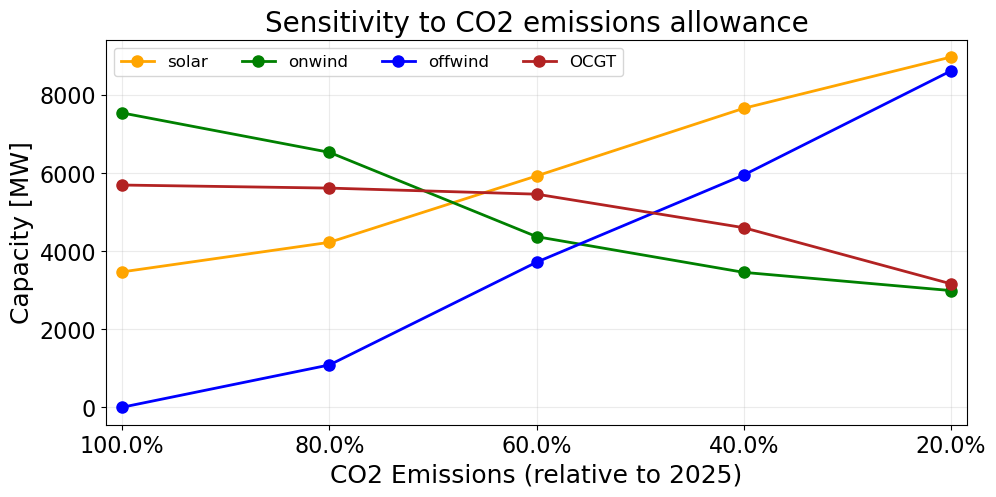

In [83]:
capacity_comparison = {}

for rel, results in partF.items():
    scenario_label = f"{rel/co2_allowance:.1%}"
    capacities = results["capacities"]
    capacity_comparison[scenario_label] = capacities

# Create DataFrame for easier viewing
capacity_df = pd.DataFrame(capacity_comparison).T
capacity_df = capacity_df[["solar", "onwind", "offwind", "OCGT"]].fillna(0.0)
print("\nCapacities (MW):")
display(capacity_df.round(2))

print("CO2 allowance would be", np.round(rel_allowance/1e12, 3), "Mt" )
print()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
techs_to_plot = ["solar", "onwind", "offwind", "OCGT"]

for tech in techs_to_plot:
    if tech in capacity_df.columns:
        ax.plot(
            capacity_df.index,
            capacity_df[tech],
            marker="o",
            linewidth=2,
            markersize=8,
            label=tech,
            color=colors.get(tech)
        )

ax.set_xlabel("CO2 Emissions (relative to 2025)", fontsize=LABEL_SIZE)
ax.set_ylabel("Capacity [MW]", fontsize=LABEL_SIZE)
ax.set_title("Sensitivity to CO2 emissions allowance", fontsize=TITLE_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=LEGEND_SIZE, loc="upper left", ncol=4)
ax.margins(x=0.02, y=0.05)
plt.tight_layout(pad=0.8)
plt.show()


## Part G

### Saving base model from part D to compare later on in this model

In [53]:
# @title Save base model before CH4 changes

if hasattr(n3, "model") and hasattr(n3.model, "solver_model"):
    n3.model.solver_model = None

n3_base = n3.copy()

In [54]:
countries = ["DK1", "DK2", "DE", "SE", "NO"]

# -----------------------------
# 1. Add carriers
# -----------------------------
for carrier in ["methane", "load_shedding", "OCGT"]:
    if carrier not in n3.carriers.index:
        n3.add("Carrier", carrier)

# -----------------------------
# 2. Add methane buses
# -----------------------------
for bus in countries:
    gas_bus = f"{bus}_gas"
    if gas_bus not in n3.buses.index:
        n3.add("Bus", gas_bus, carrier="methane")


### Building model

In [55]:
# -----------------------------
# Add methane supply
# -----------------------------
# Simple version: gas enters the system from Norway
# The cost here is the methane fuel cost in EUR/MWh_th

# -----------------------------
# 3. Add load shedding at all electricity buses
# -----------------------------
for bus in countries:
    name = f"{bus}_load_shedding"
    if name not in n3.generators.index:
        n3.add(
            "Generator",
            name,
            bus=bus,
            carrier="load_shedding",
            p_nom=float(demand_3[bus].max()),
            marginal_cost=10000,
        )


# -----------------------------
# 4. Remove old methane supplies if they exist
# -----------------------------
old_methane_supplies = [g for g in n3.generators.index if g.endswith("_methane_supply")]
if len(old_methane_supplies) > 0:
    n3.remove("Generator", old_methane_supplies)

# -----------------------------
# 5. Add one methane supply entry point in Norway
# -----------------------------
if "NO_methane_supply" not in n3.generators.index:
    n3.add(
        "Generator",
        "NO_methane_supply",
        bus="NO_gas",
        carrier="methane",
        p_nom=1e9,
        marginal_cost=costs.at["gas", "fuel"],
    )

# -----------------------------
# 6. Remove old electricity-side OCGT generators
# -----------------------------
old_ocgts = [g for g in [f"{bus}_OCGT" for bus in countries] if g in n3.generators.index]
if len(old_ocgts) > 0:
    n3.remove("Generator", old_ocgts)

# -----------------------------
# 7. Add OCGT as gas-to-power Links
# -----------------------------
# DK1 and DK2 are extendable
for bus in ["DK1", "DK2"]:
    link_name = f"{bus}_OCGT"
    if link_name in n3.links.index:
        n3.remove("Link", link_name)

    n3.add(
        "Link",
        link_name,
        bus0=f"{bus}_gas",
        bus1=bus,
        carrier="OCGT",
        p_nom_extendable=True,
        efficiency=costs.at["OCGT", "efficiency"],
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "VOM"],
    )

# DE, SE, NO are fixed
for bus in ["DE", "SE", "NO"]:
    link_name = f"{bus}_OCGT"
    if link_name in n3.links.index:
        n3.remove("Link", link_name)

    n3.add(
        "Link",
        link_name,
        bus0=f"{bus}_gas",
        bus1=bus,
        carrier="OCGT",
        p_nom=neighbor_caps.loc[bus, "ocgt"],
        efficiency=costs.at["OCGT", "efficiency"],
        marginal_cost=costs.at["OCGT", "VOM"],
    )




### Adding CH4 Pipelines to the network

In [56]:
# -----------------------------
# Add CH4 pipelines
# -----------------------------
gas_pipe_data = pd.DataFrame(
    [
        ["DK1", "DK2", 200, 4000],
        ["DK1", "DE", 300, 8000],
        ["DK1", "NO", 500, 10000],
        ["DK1", "SE", 150, 5000],
        ["DK2", "SE", 100, 3000],
    ],
    columns=["bus0", "bus1", "length_km", "p_nom"]
)

loss_per_1000km = 0.02
pipe_marginal_cost = 0.01

for _, row in gas_pipe_data.iterrows():
    eta = 1 - loss_per_1000km * row.length_km / 1000

    name_fwd = f"pipe_{row.bus0}_{row.bus1}"
    name_rev = f"pipe_{row.bus1}_{row.bus0}"

    if name_fwd in n3.links.index:
        n3.remove("Link", name_fwd)
    if name_rev in n3.links.index:
        n3.remove("Link", name_rev)

    n3.add(
        "Link",
        name_fwd,
        bus0=f"{row.bus0}_gas",
        bus1=f"{row.bus1}_gas",
        carrier="methane",
        p_nom=row.p_nom,
        efficiency=eta,
        marginal_cost=pipe_marginal_cost,
    )

    n3.add(
        "Link",
        name_rev,
        bus0=f"{row.bus1}_gas",
        bus1=f"{row.bus0}_gas",
        carrier="methane",
        p_nom=row.p_nom,
        efficiency=eta,
        marginal_cost=pipe_marginal_cost,
    )

### Run network

In [57]:
# @title Solve CH4 pipeline case

status = n3.optimize(solver_name="highs", include_objective_constant=False)
print("Solve status:", status)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████████████████████████████████████████████| 12/12 [00:00<00:00, 296.45it/s]
INFO:linopy.io: Writing time: 0.41s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 481816 primals, 1077496 duals
Objective: 4.01e+12
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_

Solve status: ('ok', 'optimal')


### Comparison between model versions

In [58]:
# @title Compare electricity and CH4 transport

gas_pipe_names = [l for l in n3.links.index if l.startswith("pipe_")]
gas_pipe_names_ok = [l for l in gas_pipe_names if l in n3.links_t.p0.columns]

print("Defined pipe links:")
print(gas_pipe_names)
print("Pipe links with solved results:")
print(gas_pipe_names_ok)

electricity_transport_MWh = n3.lines_t.p0.abs().sum().sum()

if len(gas_pipe_names_ok) > 0:
    gas_transport_MWh = n3.links_t.p0[gas_pipe_names_ok].abs().sum().sum()
else:
    gas_transport_MWh = 0.0

transport_compare = pd.Series({
    "Electricity transport [MWh]": electricity_transport_MWh,
    "CH4 pipeline transport [MWh_th]": gas_transport_MWh
})

display(transport_compare.round(2))

Defined pipe links:
['pipe_DK1_DK2', 'pipe_DK2_DK1', 'pipe_DK1_DE', 'pipe_DE_DK1', 'pipe_DK1_NO', 'pipe_NO_DK1', 'pipe_DK1_SE', 'pipe_SE_DK1', 'pipe_DK2_SE', 'pipe_SE_DK2']
Pipe links with solved results:
['pipe_DK1_DK2', 'pipe_DK2_DK1', 'pipe_DK1_DE', 'pipe_DE_DK1', 'pipe_DK1_NO', 'pipe_NO_DK1', 'pipe_DK1_SE', 'pipe_SE_DK1', 'pipe_DK2_SE', 'pipe_SE_DK2']


Electricity transport [MWh]        4.563264e+07
CH4 pipeline transport [MWh_th]    2.005958e+08
dtype: float64

In [59]:
def get_capacity_summary(net):
    gen = net.generators.copy()

    # remove non-real supply/slack technologies
    exclude_supply = gen.index.str.contains("methane_supply|gas_supply", case=False, na=False)
    exclude_ls = gen["carrier"] == "load_shedding"
    gen = gen[~(exclude_supply | exclude_ls)]

    # group generator capacities
    gen_caps = gen.groupby("carrier")["p_nom_opt"].sum()

    # rename base-case gas generator category to OCGT
    gen_caps = gen_caps.rename(index={"gas": "OCGT"})

    # add OCGT links from CH4 case
    link_caps = pd.Series(dtype=float)
    ocgt_links = net.links.index[net.links.carrier == "OCGT"]
    if len(ocgt_links) > 0:
        link_caps["OCGT"] = net.links.loc[ocgt_links, "p_nom_opt"].fillna(
            net.links.loc[ocgt_links, "p_nom"]
        ).sum()

    # storage
    store_caps = pd.Series(dtype=float)
    if len(net.storage_units) > 0:
        store_caps["battery"] = net.storage_units["p_nom_opt"].sum()

    out = pd.concat([gen_caps, link_caps, store_caps])
    out = out.groupby(out.index).sum()

    tech_order = ["solar", "onwind", "offwind", "battery", "OCGT"]
    out = out.reindex(tech_order).fillna(0)

    return out

### Display summary

In [60]:
cap_base = get_capacity_summary(n3_base)
cap_ch4 = get_capacity_summary(n3)

cap_compare = pd.concat(
    [cap_base.rename("Base"), cap_ch4.rename("CH4 pipelines")],
    axis=1
).fillna(0)

# Add this here
cap_delta = cap_compare["CH4 pipelines"] - cap_compare["Base"]
display(cap_delta.round(2))

display(cap_compare.round(2))

print("Base summary")
display(cap_base)

print("CH4 summary")
display(cap_ch4)

print("Combined")
display(cap_compare)

solar       4728.50
onwind     22670.34
offwind        0.00
battery    24141.13
OCGT           0.00
dtype: float64

,Base,CH4 pipelines
solar,54918.46,59646.96
onwind,69542.38,92212.72
offwind,5742.00,5742.00
battery,652.38,24793.51
OCGT,123991.46,123991.46


Base summary


solar       54918.463868
onwind      69542.379796
offwind      5742.000000
battery       652.381203
OCGT       123991.460000
dtype: float64

CH4 summary


solar       59646.964004
onwind      92212.717966
offwind      5742.000000
battery     24793.512400
OCGT       123991.460000
dtype: float64

Combined


,Base,CH4 pipelines
solar,54918.463868,59646.964004
onwind,69542.379796,92212.717966
offwind,5742.000000,5742.000000
battery,652.381203,24793.512400
OCGT,123991.460000,123991.460000


### Plots

In [61]:
# @title Plot settings

if "colors" not in globals():
    colors = {
        "solar": "orange",
        "onwind": "green",
        "offwind": "blue",
        "OCGT": "firebrick",
        "battery": "limegreen",
        "load_shedding": "gray",
        "methane_pipeline": "saddlebrown",
        "electricity": "black",
        "methane": "saddlebrown",
    }

colors["load_shedding"] = colors.get("load_shedding", "gray")
colors["methane_pipeline"] = colors.get("methane_pipeline", "saddlebrown")
colors["OCGT"] = colors.get("OCGT", "firebrick")
colors["electricity"] = colors.get("electricity", "black")
colors["methane"] = colors.get("methane", "saddlebrown")

if "TITLE_SIZE" not in globals():
    TITLE_SIZE = 20
if "LABEL_SIZE" not in globals():
    LABEL_SIZE = 18
if "TICK_SIZE" not in globals():
    TICK_SIZE = 16
if "LEGEND_SIZE" not in globals():
    LEGEND_SIZE = 12
if "GRID_ALPHA" not in globals():
    GRID_ALPHA = 0.25

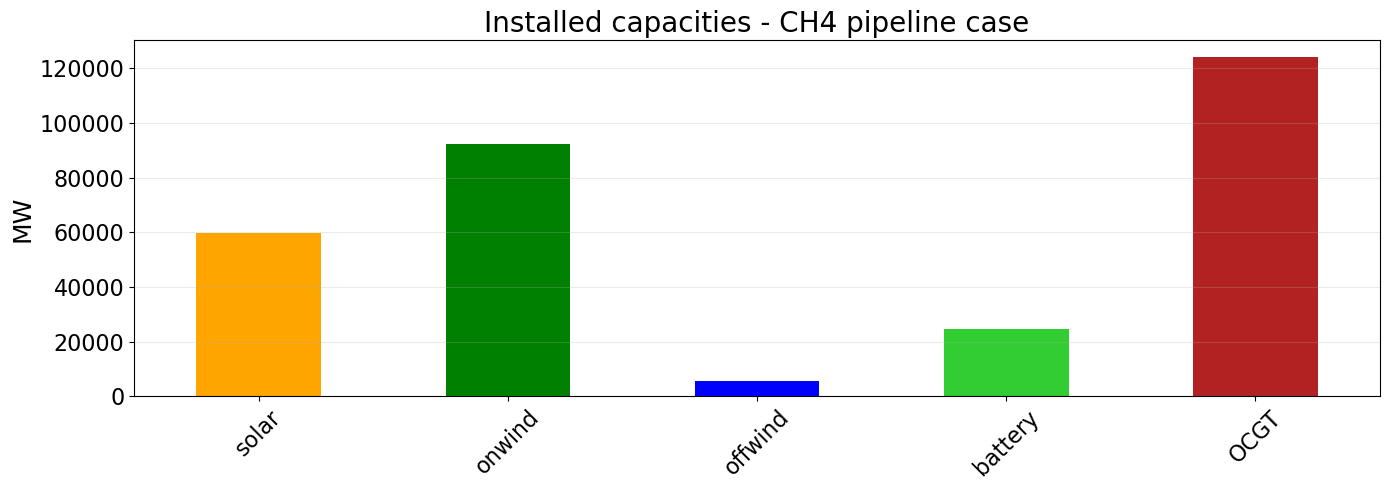

In [62]:
# @title Installed capacities - CH4 case

cap_ch4 = get_capacity_summary(n3)

fig, ax = plt.subplots(figsize=(14, 5))

bar_colors = [colors.get(i, "gray") for i in cap_ch4.index]
cap_ch4.plot(kind="bar", ax=ax, color=bar_colors)

ax.set_ylabel("MW", fontsize=LABEL_SIZE)
ax.set_title("Installed capacities - CH4 pipeline case", fontsize=TITLE_SIZE)
ax.tick_params(axis="x", labelsize=TICK_SIZE, rotation=45)
ax.tick_params(axis="y", labelsize=TICK_SIZE)
ax.grid(axis="y", alpha=GRID_ALPHA)

plt.tight_layout()
plt.show()

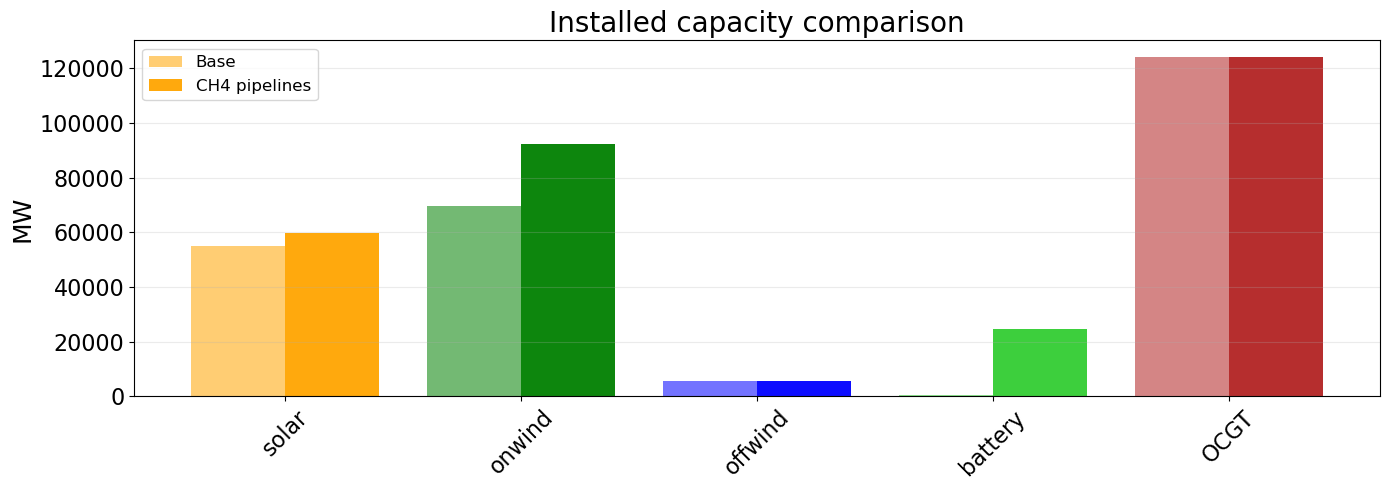

In [63]:
# @title Installed capacities - Base vs CH4

cap_base = get_capacity_summary(n3_base)
cap_ch4 = get_capacity_summary(n3)

cap_compare = pd.concat(
    [cap_base.rename("Base"), cap_ch4.rename("CH4 pipelines")],
    axis=1
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(cap_compare.index))
width = 0.4

base_colors = [colors.get(i, "gray") for i in cap_compare.index]
ch4_colors = [colors.get(i, "gray") for i in cap_compare.index]

ax.bar([i - width/2 for i in x], cap_compare["Base"], width=width, color=base_colors, alpha=0.55, label="Base")
ax.bar([i + width/2 for i in x], cap_compare["CH4 pipelines"], width=width, color=ch4_colors, alpha=0.95, label="CH4 pipelines")

ax.set_xticks(list(x))
ax.set_xticklabels(cap_compare.index, rotation=45, fontsize=TICK_SIZE)
ax.set_ylabel("MW", fontsize=LABEL_SIZE)
ax.set_title("Installed capacity comparison", fontsize=TITLE_SIZE)
ax.tick_params(axis="y", labelsize=TICK_SIZE)
ax.grid(axis="y", alpha=GRID_ALPHA)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.show()

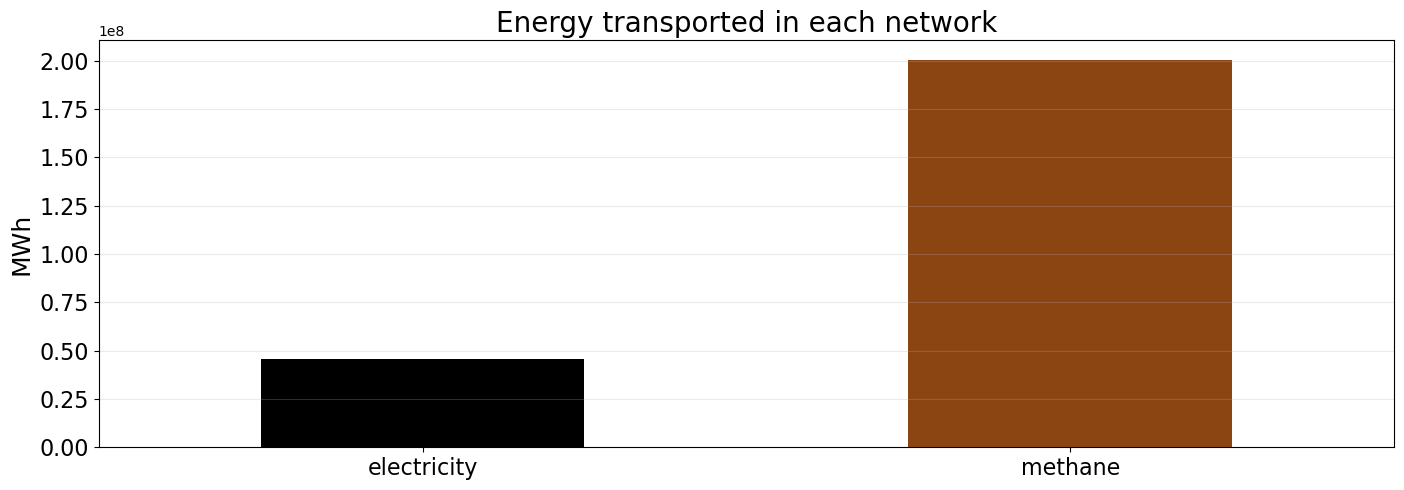

DK1-DK2    26382059.41
DK1-DE     16540897.18
DK1-NO     87597625.40
DK1-SE     43798692.56
DK2-SE     26276531.17
dtype: float64

In [64]:
# @title Energy transported in each network

electricity_transport_MWh = n3.lines_t.p0.abs().sum().sum()

corridors = [
    ("DK1", "DK2"),
    ("DK1", "DE"),
    ("DK1", "NO"),
    ("DK1", "SE"),
    ("DK2", "SE"),
]

corridor_transport = {}

for a, b in corridors:
    fwd = n3.links_t.p0[f"pipe_{a}_{b}"]
    rev = n3.links_t.p0[f"pipe_{b}_{a}"]
    corridor_transport[f"{a}-{b}"] = (fwd - rev).abs().sum()

gas_transport_MWh = pd.Series(corridor_transport).sum()

transport_plot = pd.Series({
    "electricity": electricity_transport_MWh,
    "methane": gas_transport_MWh
})

fig, ax = plt.subplots(figsize=(14, 5))

bar_colors = [colors.get(i, "gray") for i in transport_plot.index]
transport_plot.plot(kind="bar", ax=ax, color=bar_colors)

ax.set_ylabel("MWh", fontsize=LABEL_SIZE)
ax.set_title("Energy transported in each network", fontsize=TITLE_SIZE)
ax.tick_params(axis="x", labelsize=TICK_SIZE, rotation=0)
ax.tick_params(axis="y", labelsize=TICK_SIZE)
ax.grid(axis="y", alpha=GRID_ALPHA)

plt.tight_layout()
plt.show()

display(pd.Series(corridor_transport).round(2))

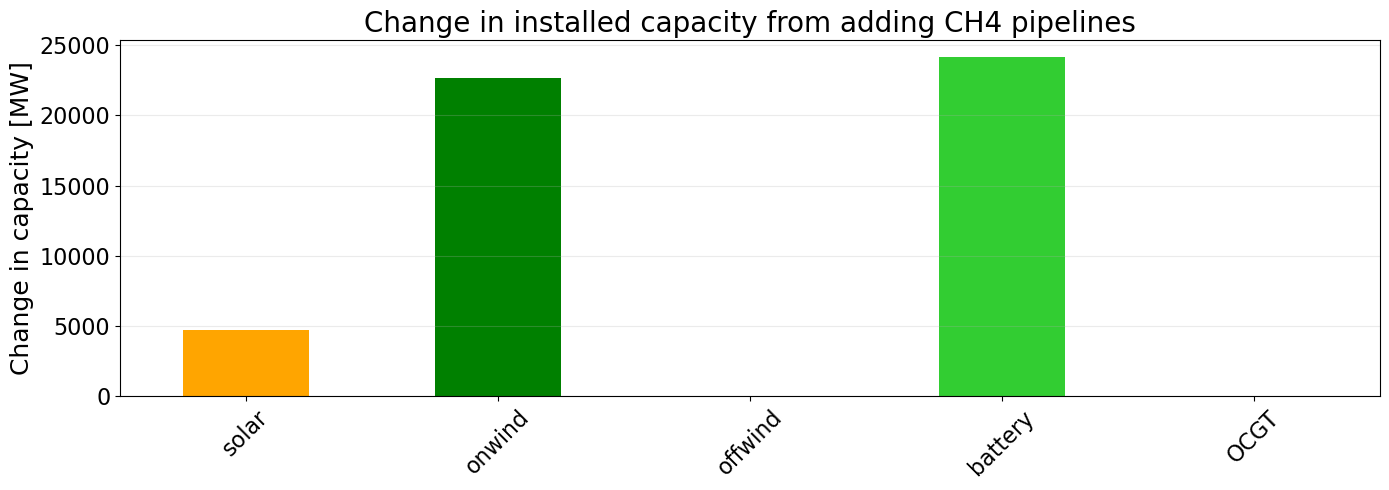

In [65]:
cap_delta = cap_compare["CH4 pipelines"] - cap_compare["Base"]

fig, ax = plt.subplots(figsize=(14, 5))

bar_colors = [colors.get(i, "gray") for i in cap_delta.index]
cap_delta.plot(kind="bar", ax=ax, color=bar_colors)

ax.set_ylabel("Change in capacity [MW]", fontsize=LABEL_SIZE)
ax.set_title("Change in installed capacity from adding CH4 pipelines", fontsize=TITLE_SIZE)
ax.tick_params(axis="x", labelsize=TICK_SIZE, rotation=45)
ax.tick_params(axis="y", labelsize=TICK_SIZE)
ax.grid(axis="y", alpha=GRID_ALPHA)

plt.tight_layout()
plt.show()

## Part H

Building upon **Part G**

The following approach reduces the limit of the $\mathrm{CO_2}$, optimises the problem and then calcualtes the difference of energy price with forced $\mathrm{CO_2}$ production wrt to today's energy price. The difference is the required $\mathrm{CO_2}$ emitting tax. For automisation, the process is automated for comparison of various reductions.

In [ ]:
# ── PART H: CO2 shadow price from Part G network ────────────────────────────
import copy

# ── 0. Configuration ─────────────────────────────────────────────────────────
DK_CO2_TARGET_MT = 1.0   # Danish energy sector 2030 target [Mt CO2]
DK_BUS_PREFIX    = "DK"  # buses whose loads count as Danish demand
SOLVER           = "highs"

# ── 1. Deep-copy Part G network (n3 with CH4 pipelines) ──────────────────────
# Wipe the solver object so deepcopy doesn't choke
if hasattr(n3, "model") and hasattr(n3.model, "solver_model"):
    n3.model.solver_model = None
co2 = copy.deepcopy(n3)

# ── 2. CO2 intensities — combustion carriers only (g CO2 / MWh_th input) ─────
# In Part G, OCGT is a Link: bus0=gas bus, bus1=electricity bus.
# PyPSA evaluates co2_emissions on the *input* carrier (methane),
# so we set intensity on "methane", NOT on "OCGT".
# Renewables have zero operational emissions → leave at 0.

# Charge emissions at combustion point (OCGT link), not at gas supply
if "methane" in co2.carriers.index:
    co2.carriers.at["methane", "co2_emissions"] = 0.0
else:
    co2.add("Carrier", "methane", co2_emissions=0.0)

# OCGT link consumes gas on bus0 — charge combustion emissions here
if "OCGT" in co2.carriers.index:
    co2.carriers.at["OCGT", "co2_emissions"] = 490e3

# Confirm no spurious lifecycle emissions on renewables
for carrier in ["solar", "onwind", "offwind", "hydrogen", "electricity"]:
    if carrier in co2.carriers.index:
        co2.carriers.at[carrier, "co2_emissions"] = 0.0

# ── 3. Demand-proportional CO2 budget ────────────────────────────────────────
# DK makes up a fraction of total system demand → scale DK target proportionally
dk_demand    = co2.loads_t.p_set.loc[
                   :, co2.loads.bus.str.startswith(DK_BUS_PREFIX)
               ].values.sum()
total_demand = co2.loads_t.p_set.values.sum()
scale_factor = total_demand / dk_demand

system_co2_budget_g = DK_CO2_TARGET_MT * 1e12 * scale_factor

print(f"DK demand share:    {dk_demand / total_demand * 100:.1f}% of system")
print(f"Scale factor:       {scale_factor:.2f}x")
print(f"System CO2 budget:  {system_co2_budget_g / 1e12:.2f} Mt CO2")

# ── 4. Add GlobalConstraint ───────────────────────────────────────────────────
if "CO2Limit" not in co2.global_constraints.index:
    co2.add(
        "GlobalConstraint", "CO2Limit",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=system_co2_budget_g,
    )
else:
    co2.global_constraints.at["CO2Limit", "constant"] = system_co2_budget_g

# ── 5. POINT A — baseline from already-solved n3 (free, no extra solve) ───────
def calc_emissions_g(network, carrier_table):
    """Sum operational CO2 emissions in grams across generators and links."""
    # Generators: emissions on output carrier
    gen_intensity = network.generators["carrier"].map(
        carrier_table["co2_emissions"]
    ).fillna(0.0)
    gen_co2 = network.generators_t.p.mul(gen_intensity, axis=1).values.sum()

    # Links: emissions on INPUT (bus0) carrier — correct for gas-to-power links
    link_intensity = network.links["carrier"].map(
        carrier_table["co2_emissions"]
    ).fillna(0.0)
    # p0 is the flow into the link (gas consumed), sign convention: positive = consuming
    link_co2 = network.links_t.p0.mul(link_intensity, axis=1).values.sum()

    return gen_co2 + link_co2

# Point A: baseline emissions from Part G optimisation (no CO2 constraint)
baseline_g = calc_emissions_g(n3, co2.carriers)
print(f"\nPoint A — Part G baseline (no CO2 limit): {baseline_g / 1e12:.3f} Mt CO2")
print(f"           CO2 price: 0 €/tonne")

# ── 6. POINT B — single constrained solve ────────────────────────────────────
print(f"\nSolving with CO2 cap of {system_co2_budget_g / 1e12:.2f} Mt...")
co2.optimize(solver_name=SOLVER)

mu           = co2.global_constraints.at["CO2Limit", "mu"]
co2_price    = mu * 1e6                          # convert €/g → €/tonne
actual_co2_g = calc_emissions_g(co2, co2.carriers)
reduction    = (1 - actual_co2_g / baseline_g) * 100

print(f"\nPoint B — constrained solve:")
print(f"  Target:             {system_co2_budget_g / 1e12:.3f} Mt CO2")
print(f"  Actual emissions:   {actual_co2_g / 1e12:.3f} Mt CO2")
print(f"  Reduction:          {reduction:.1f}% vs Part G baseline")
print(f"  CO2 shadow price:   {co2_price:.1f} €/tonne")

# ── 7. Capacity mix: Part G baseline → constrained ───────────────────────────
print("\nCapacity mix (Part G unconstrained → CO2-constrained) [MW]:")
for carrier in ["solar", "onwind", "offwind"]:
    base = n3.generators.loc[n3.generators.carrier == carrier, "p_nom_opt"].sum()
    cons = co2.generators.loc[co2.generators.carrier == carrier, "p_nom_opt"].sum()
    print(f"  {carrier:<10}  {base:>8.0f}  →  {cons:>8.0f} MW")

# OCGT is a Link in Part G
ocgt_base = n3.links.loc[n3.links.carrier == "OCGT", "p_nom_opt"].sum()
ocgt_cons  = co2.links.loc[co2.links.carrier == "OCGT", "p_nom_opt"].sum()
print(f"  {'OCGT':<10}  {ocgt_base:>8.0f}  →  {ocgt_cons:>8.0f} MW")

## Part I

In [ ]:
weather_folder = Path("WeatherData")

# -----------------------------
# Heating demand assumptions
# -----------------------------

heat_demand_twh = {
    "DK1": 25.0,   # assumed annual heat demand in DK1 [TWh_th]
    "DK2": 10.0,   # assumed annual heat demand in DK2 [TWh_th]
}

T_threshold = 17.0          # heating threshold [degC]
hot_water_share = 0.15      # constant hot-water share of annual heat demand

# -----------------------------
# Heating technology costs from costs dataframe
# -----------------------------

discount_rate = 0.04

def annuity(r, n):
    return r / (1 - (1 + r) ** (-n))

heat_pump_tech = "central air-sourced heat pump"
gas_boiler_tech = "central gas boiler"
thermal_storage_tech = "central water tank storage"

# Read rows
hp = costs.loc[heat_pump_tech]
gb = costs.loc[gas_boiler_tech]
ts = costs.loc[thermal_storage_tech]

# Efficiencies
COP = float(hp["efficiency"])
gas_boiler_efficiency = float(gb["efficiency"])

# Heat pump:
# The cost table investment is interpreted as EUR/MW_th.
# PyPSA Link p_nom is defined on bus0, i.e. MW_el input.
# Therefore we multiply by COP to convert EUR/MW_th/year to EUR/MW_el/year.
hp_fixed_per_MW_th = hp["investment"] * (
    annuity(discount_rate, hp["lifetime"]) + hp["FOM"] / 100
)

heat_pump_capital_cost = hp_fixed_per_MW_th * COP

# Gas boiler:
# The gas boiler is placed directly on the heat bus, so p_nom is MW_th.
gas_boiler_capital_cost = gb["investment"] * (
    annuity(discount_rate, gb["lifetime"]) + gb["FOM"] / 100
)

# Thermal storage:
# StorageUnit p_nom is MW_th and max_hours determines energy capacity.
# Therefore capital_cost should be EUR/MW_th/year.
# The storage cost row is interpreted as EUR/MWh_th/year, so multiply by max_hours later.
thermal_storage_energy_cost = ts["investment"] * (
    annuity(discount_rate, ts["lifetime"]) + ts["FOM"] / 100
)

thermal_storage_hours = 48

# Variable costs
heat_pump_marginal_cost = float(hp["VOM"])
gas_boiler_vom = float(gb["VOM"])

try:
    gas_cost = float(costs.at["gas", "fuel"])   # EUR/MWh_fuel
except:
    gas_cost = 50.0

gas_boiler_marginal_cost = gas_cost / gas_boiler_efficiency + gas_boiler_vom

# -----------------------------
# Use task d model
# -----------------------------

n_i_base = n3_base.copy()

# -----------------------------
# Print assumptions
# -----------------------------

print("Heating-sector assumptions:")
print(f"Heat demand DK1: {heat_demand_twh['DK1']:.1f} TWh_th/year")
print(f"Heat demand DK2: {heat_demand_twh['DK2']:.1f} TWh_th/year")
print(f"Heating threshold: {T_threshold:.1f} °C")
print(f"Hot-water share: {100 * hot_water_share:.1f} %")
print()
print("Heating technology assumptions from costs dataframe:")
print(f"Heat pump COP: {COP:.2f}")
print(f"Gas boiler efficiency: {gas_boiler_efficiency:.3f}")
print(f"Heat pump capital cost: {heat_pump_capital_cost:.0f} EUR/MW_el/year")
print(f"Gas boiler capital cost: {gas_boiler_capital_cost:.0f} EUR/MW_th/year")
print(f"Thermal storage energy cost: {thermal_storage_energy_cost:.1f} EUR/MWh_th/year")
print(f"Thermal storage duration: {thermal_storage_hours:.0f} h")
print(f"Heat pump marginal cost: {heat_pump_marginal_cost:.2f} EUR/MWh_el")
print(f"Gas boiler marginal cost: {gas_boiler_marginal_cost:.2f} EUR/MWh_th")
print()
print("Base model size:")
print(f"Number of buses: {len(n_i_base.buses)}")
print(f"Number of generators: {len(n_i_base.generators)}")
print(f"Number of lines: {len(n_i_base.lines)}")
print(f"Number of links: {len(n_i_base.links)}")
print(f"Number of storage units: {len(n_i_base.storage_units)}")
print(f"Number of snapshots: {len(n_i_base.snapshots)}")

Task i base model is ready.
Using n3_base: clean interconnected electricity model from Task d.

Heating-sector assumptions:
Heat demand DK1: 25.0 TWh_th/year
Heat demand DK2: 10.0 TWh_th/year
Heating threshold: 17.0 °C
Hot-water share: 15.0 %

Heating technology assumptions from costs dataframe:
Heat pump technology: central air-sourced heat pump
Gas boiler technology: central gas boiler
Thermal storage technology: central water tank storage
Heat pump COP: 3.15
Gas boiler efficiency: 1.035
Heat pump capital cost: 209670 EUR/MW_el/year
Gas boiler capital cost: 5763 EUR/MW_th/year
Thermal storage energy cost: 167.6 EUR/MWh_th/year
Thermal storage duration: 48 h
Heat pump marginal cost: 2.32 EUR/MWh_el
Gas boiler marginal cost: 24.85 EUR/MWh_th

Base model size:
Number of buses: 7
Number of generators: 22
Number of lines: 5
Number of links: 4
Number of storage units: 2
Number of snapshots: 8760


Temperature profile loaded from 2019-01-01 01:00:00 to 2020-01-01 00:00:00
Number of temperature hours: 8759


Temperature profile loaded from 2019-01-01 01:00:00 to 2020-01-01 00:00:00
Number of temperature hours: 8759


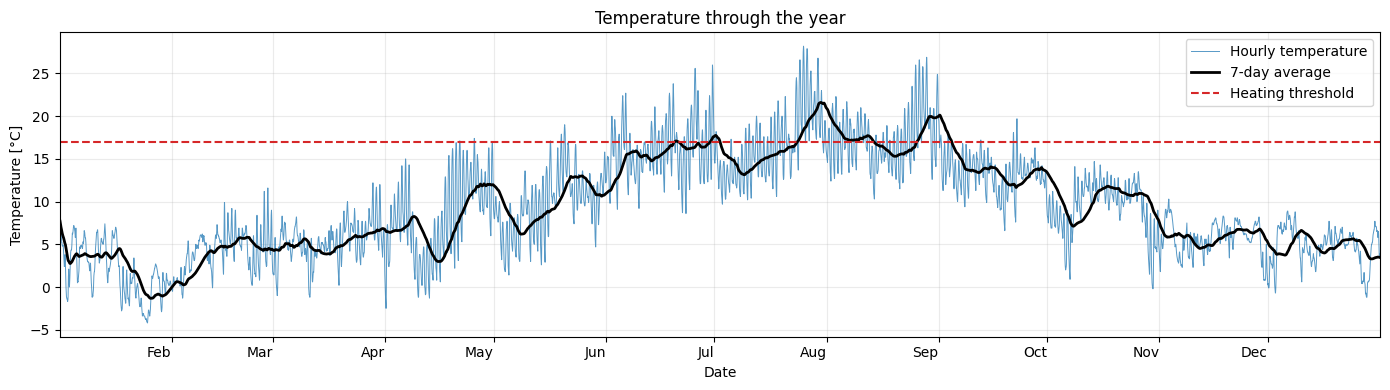

In [100]:
#Read the weather data

rows = []

for file in sorted(weather_folder.glob("*.txt")):
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            try:
                obj = json.loads(line)
            except:
                continue

            props = obj.get("properties", {})

            if props.get("parameterId") != "mean_temp":
                continue

            if props.get("timeResolution") != "hour":
                continue

            if props.get("value") is None:
                continue

            t = (
                pd.to_datetime(props["from"], utc=True)
                .tz_convert("Europe/Copenhagen")
                .tz_localize(None)
                .floor("h")
            )

            rows.append((t, float(props["value"])))

temp = (
    pd.DataFrame(rows, columns=["time", "temp"])
    .groupby("time")["temp"]
    .mean()
    .sort_index()
 )

print(f"Temperature profile loaded from {temp.index.min()} to {temp.index.max()}")
print(f"Number of temperature hours: {len(temp)}")

fig, ax = plt.subplots(figsize=(14, 4))
temp.plot(ax=ax, color="tab:blue", linewidth=0.7, alpha=0.75, label="Hourly temperature")
temp.rolling(24 * 7, min_periods=1).mean().plot(ax=ax, color="black", linewidth=2, label="7-day average")
ax.axhline(17, color="tab:red", linestyle="--", linewidth=1.5, label="Heating threshold")
ax.set_title("Temperature through the year")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature [°C]")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(temp.index.min(), temp.index.max() - pd.Timedelta(hours=1))
plt.setp(ax.get_xticklabels(), rotation=0)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


### Creating Heat demand from temperature data

In [101]:
# Model snapshots from the Task D model
snapshots = n_i_base.snapshots

# Snapshot weights for converting MW to MWh
if hasattr(n_i_base.snapshot_weightings, "generators"):
    weights = n_i_base.snapshot_weightings.generators.reindex(snapshots).fillna(1.0)
elif "generators" in n_i_base.snapshot_weightings.columns:
    weights = n_i_base.snapshot_weightings["generators"].reindex(snapshots).fillna(1.0)
elif "objective" in n_i_base.snapshot_weightings.columns:
    weights = n_i_base.snapshot_weightings["objective"].reindex(snapshots).fillna(1.0)
else:
    weights = pd.Series(1.0, index=snapshots)

# Clean and align temperature profile to model snapshots
temp_aligned = temp.copy()
temp_aligned = temp_aligned.sort_index()
temp_aligned = temp_aligned[~temp_aligned.index.duplicated(keep="first")]

temp_aligned = (
    temp_aligned
    .reindex(snapshots)
    .interpolate(method="time", limit_direction="both")
    .ffill()
    .bfill()
)

# Heating Degree Hours
HDH = (T_threshold - temp_aligned).clip(lower=0.0)

if (HDH * weights).sum() == 0:
    raise ValueError("Heating Degree Hours are zero. Check temperature data and T_threshold.")

# Create heat demand profiles for DK1 and DK2
heat_demand = pd.DataFrame(index=snapshots)

for zone in ["DK1", "DK2"]:
    annual_heat_mwh = heat_demand_twh[zone] * 1e6

    # Split annual heat demand into:
    # 1) temperature-dependent space heating
    # 2) constant hot-water demand
    space_heat_mwh = annual_heat_mwh * (1 - hot_water_share)
    hot_water_mwh = annual_heat_mwh * hot_water_share

    # Space heating follows Heating Degree Hours
    heat_space = HDH / (HDH * weights).sum() * space_heat_mwh

    # Hot-water demand is constant across the year
    heat_hot_water = pd.Series(1.0, index=snapshots)
    heat_hot_water = heat_hot_water / (heat_hot_water * weights).sum() * hot_water_mwh

    # Total heat demand
    heat_demand[zone] = heat_space + heat_hot_water

# -----------------------------
# Checks
# -----------------------------

annual_heat_check = heat_demand.mul(weights, axis=0).sum() / 1e6
peak_heat_check = heat_demand.max()

print("Temperature and heat demand profiles created.")
print()
print(f"Temperature period after alignment: {temp_aligned.index.min()} to {temp_aligned.index.max()}")
print(f"Mean temperature: {temp_aligned.mean():.2f} °C")
print(f"Minimum temperature: {temp_aligned.min():.2f} °C")
print(f"Maximum temperature: {temp_aligned.max():.2f} °C")
print()
print("Annual heat demand check [TWh_th]:")
display(annual_heat_check.round(2))

print("Peak heat demand [MW_th]:")
display(peak_heat_check.round(2))


Temperature and heat demand profiles created.

Temperature period after alignment: 2019-01-01 00:00:00 to 2019-12-31 23:00:00
Mean temperature: 9.43 °C
Minimum temperature: -4.20 °C
Maximum temperature: 28.20 °C

Annual heat demand check [TWh_th]:


DK1    25.0
DK2    10.0
dtype: float64

Peak heat demand [MW_th]:


DK1    6937.62
DK2    2775.05
dtype: float64

### Adding the heating sector to model

In [ ]:
# Minimum share of annual heat demand that should be electrified through heat pumps
min_heat_pump_share = 0.70
max_gas_boiler_share = 1 - min_heat_pump_share

# Start from the Task D model
n_i = n_i_base.copy()

# Add new carriers if they do not already exist
for carrier in ["heat", "heat_pump", "gas_boiler", "thermal_storage"]:
    if carrier not in n_i.carriers.index:
        n_i.add("Carrier", carrier)

# Add heating sector for DK1 and DK2
for zone in ["DK1", "DK2"]:

    heat_bus = f"{zone}_heat"

    # Heat bus
    if heat_bus not in n_i.buses.index:
        n_i.add(
            "Bus",
            heat_bus,
            carrier="heat",
        )

    # Heat demand
    n_i.add(
        "Load",
        f"{zone}_heat_demand",
        bus=heat_bus,
        carrier="heat",
        p_set=heat_demand[zone],
    )

    # Heat pump: electricity -> heat
    # bus0 is electricity input, bus1 is heat output
    n_i.add(
        "Link",
        f"{zone}_heat_pump",
        bus0=zone,
        bus1=heat_bus,
        carrier="heat_pump",
        p_nom_extendable=True,
        efficiency=COP,
        capital_cost=heat_pump_capital_cost,
        marginal_cost=heat_pump_marginal_cost,
    )

    # Gas boiler: backup heat production
    n_i.add(
        "Generator",
        f"{zone}_gas_boiler",
        bus=heat_bus,
        carrier="gas_boiler",
        p_nom_extendable=True,
        efficiency=gas_boiler_efficiency,
        capital_cost=gas_boiler_capital_cost,
        marginal_cost=gas_boiler_marginal_cost,
    )

    # Thermal storage
    # StorageUnit p_nom is MW_th, and max_hours defines MWh_th capacity.
    n_i.add(
        "StorageUnit",
        f"{zone}_thermal_storage",
        bus=heat_bus,
        carrier="thermal_storage",
        p_nom_extendable=True,
        max_hours=thermal_storage_hours,
        efficiency_store=0.98,
        efficiency_dispatch=0.98,
        standing_loss=0.0002,
        cyclic_state_of_charge=True,
        capital_cost=thermal_storage_energy_cost * thermal_storage_hours,
    )

# Component names used later
heat_pumps = ["DK1_heat_pump", "DK2_heat_pump"]
gas_boilers = ["DK1_gas_boiler", "DK2_gas_boiler"]
thermal_stores = ["DK1_thermal_storage", "DK2_thermal_storage"]
heat_loads = ["DK1_heat_demand", "DK2_heat_demand"]


# -----------------------------
# Extra constraint for sector coupling
# -----------------------------
#
# Without this, the model may choose to supply all heat with gas boilers,
# because they are cheap and dispatchable. To make Task i a meaningful
# electricity-heating coupling scenario, gas boilers are limited to supplying
# at most 30% of annual heat demand. The remaining heat must mainly come from
# electricity through heat pumps.

def extra_functionality(n, snapshots):

    # Snapshot weights
    if hasattr(n.snapshot_weightings, "generators"):
        w = n.snapshot_weightings.generators.reindex(snapshots).fillna(1.0)
    elif "generators" in n.snapshot_weightings.columns:
        w = n.snapshot_weightings["generators"].reindex(snapshots).fillna(1.0)
    elif "objective" in n.snapshot_weightings.columns:
        w = n.snapshot_weightings["objective"].reindex(snapshots).fillna(1.0)
    else:
        w = pd.Series(1.0, index=snapshots)

    # Total weighted annual heat demand [MWh_th]
    total_heat_demand = (
        n.loads_t.p_set
        .reindex(index=snapshots, columns=heat_loads)
        .fillna(0.0)
        .mul(w, axis=0)
        .sum()
        .sum()
    )

    max_gas_boiler_heat = max_gas_boiler_share * total_heat_demand

    # Generator dispatch variables
    gen_p = n.model.variables["Generator-p"]

    # Select gas boiler dispatch
    gas_boiler_dispatch = gen_p.loc[dict(snapshot=snapshots, name=gas_boilers)]

    # Convert weights to xarray so they broadcast with linopy variables
    import xarray as xr
    w_xr = xr.DataArray(w.values, coords=[snapshots], dims=["snapshot"])

    annual_gas_boiler_heat = (gas_boiler_dispatch * w_xr).sum()

    n.model.add_constraints(
        annual_gas_boiler_heat <= max_gas_boiler_heat,
        name="gas_boiler_annual_heat_limit",
    )


print("Heating sector added to model.")
print(f"Minimum heat-pump share: {100 * min_heat_pump_share:.0f}% of annual heat demand")
print(f"Maximum gas-boiler share: {100 * max_gas_boiler_share:.0f}% of annual heat demand")
print()
print("New heat pumps:")
display(n_i.links.loc[heat_pumps, ["bus0", "bus1", "carrier", "efficiency", "capital_cost", "marginal_cost", "p_nom_extendable"]])

print("New gas boilers:")
display(n_i.generators.loc[gas_boilers, ["bus", "carrier", "efficiency", "capital_cost", "marginal_cost", "p_nom_extendable"]])

print("New thermal storage units:")
display(n_i.storage_units.loc[thermal_stores, ["bus", "carrier", "p_nom_extendable", "max_hours", "capital_cost"]])

Heating sector added to model.
Minimum heat-pump share: 70% of annual heat demand
Maximum gas-boiler share: 30% of annual heat demand

New heat pumps:


,bus0,bus1,carrier,efficiency,capital_cost,marginal_cost,p_nom_extendable
name,,,,,,,
DK1_heat_pump,DK1,DK1_heat,heat_pump,3.15,209670.249774,2.3175,True
DK2_heat_pump,DK2,DK2_heat,heat_pump,3.15,209670.249774,2.3175,True


Heating sector added to model.
Minimum heat-pump share: 70% of annual heat demand
Maximum gas-boiler share: 30% of annual heat demand

New heat pumps:


,bus0,bus1,carrier,efficiency,capital_cost,marginal_cost,p_nom_extendable
name,,,,,,,
DK1_heat_pump,DK1,DK1_heat,heat_pump,3.15,209670.249774,2.3175,True
DK2_heat_pump,DK2,DK2_heat,heat_pump,3.15,209670.249774,2.3175,True


New gas boilers:


...

,bus0,bus1,carrier,efficiency,capital_cost,marginal_cost,p_nom_extendable
name,,,,,,,
DK1_heat_pump,DK1,DK1_heat,heat_pump,3.15,209670.249774,2.3175,True
DK2_heat_pump,DK2,DK2_heat,heat_pump,3.15,209670.249774,2.3175,True


New gas boilers:


,bus,carrier,efficiency,capital_cost,marginal_cost,p_nom_extendable
name,,,,,,
DK1_gas_boiler,DK1_heat,gas_boiler,1.035,5762.71406,24.848298,True
DK2_gas_boiler,DK2_heat,gas_boiler,1.035,5762.71406,24.848298,True


New thermal storage units:


,bus,carrier,p_nom_extendable,max_hours,capital_cost
name,,,,,
DK1_thermal_storage,DK1_heat,thermal_storage,True,48.0,8045.471655
DK2_thermal_storage,DK2_heat,thermal_storage,True,48.0,8045.471655


### Optimize

In [ ]:
print(f"Number of snapshots: {len(n_i.snapshots)}")
print(f"Gas boiler heat is limited to {100 * max_gas_boiler_share:.0f}% of annual heat demand.")

n_i.optimize(
    solver_name="highs",
    include_objective_constant=False,
    extra_functionality=extra_functionality,
)

print(f"Objective value: {n_i.objective / 1e9:.3f} billion EUR")

print("\nOptimised heat pump capacities [MW_el]:")
display(n_i.links.loc[heat_pumps, ["p_nom_opt", "efficiency", "capital_cost", "marginal_cost"]])

print("\nOptimised gas boiler capacities [MW_th]:")
display(n_i.generators.loc[gas_boilers, ["p_nom_opt", "efficiency", "capital_cost", "marginal_cost"]])

print("\nOptimised thermal storage power capacities [MW_th]:")
display(n_i.storage_units.loc[thermal_stores, ["p_nom_opt", "max_hours", "capital_cost"]])

Number of snapshots: 8760
Gas boiler heat is limited to 30% of annual heat demand.


Number of snapshots: 8760
Gas boiler heat is limited to 30% of annual heat demand.


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 144.06it/s]
INFO:linopy.io: Writing time: 0.96s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 446782 primals, 998663 duals
Objective: 3.97e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance, gas_boiler_annual_heat_limit were not assigned

Number of snapshots: 8760
Gas boiler heat is limited to 30% of annual heat demand.


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 144.06it/s]
INFO:linopy.io: Writing time: 0.96s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 446782 primals, 998663 duals
Objective: 3.97e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance, gas_boiler_annual_heat_limit were not assigned

...

,p_nom_opt,efficiency,capital_cost,marginal_cost
name,,,,
DK1_heat_pump,753.202347,3.15,209670.249774,2.3175
DK2_heat_pump,369.896402,3.15,209670.249774,2.3175



Optimised gas boiler capacities [MW_th]:


,p_nom_opt,efficiency,capital_cost,marginal_cost
name,,,,
DK1_gas_boiler,5115.940323,1.035,5762.71406,24.848298
DK2_gas_boiler,1719.698032,1.035,5762.71406,24.848298



Optimised thermal storage power capacities [MW_th]:


,p_nom_opt,max_hours,capital_cost
name,,,
DK1_thermal_storage,1637.451343,48.0,8045.471655
DK2_thermal_storage,993.940789,48.0,8045.471655


### Results

In [121]:
zones = ["DK1", "DK2"]

heat_pumps = [f"{z}_heat_pump" for z in zones]
gas_boilers = [f"{z}_gas_boiler" for z in zones]
thermal_stores = [f"{z}_thermal_storage" for z in zones]
heat_loads = [f"{z}_heat_demand" for z in zones]

# Snapshot weights from the solved model
if hasattr(n_i.snapshot_weightings, "generators"):
    weights_i = n_i.snapshot_weightings.generators.reindex(n_i.snapshots).fillna(1.0)
elif "generators" in n_i.snapshot_weightings.columns:
    weights_i = n_i.snapshot_weightings["generators"].reindex(n_i.snapshots).fillna(1.0)
elif "objective" in n_i.snapshot_weightings.columns:
    weights_i = n_i.snapshot_weightings["objective"].reindex(n_i.snapshots).fillna(1.0)
else:
    weights_i = pd.Series(1.0, index=n_i.snapshots)

result_rows = []

for zone in zones:
    hp = f"{zone}_heat_pump"
    gb = f"{zone}_gas_boiler"
    store = f"{zone}_thermal_storage"
    load = f"{zone}_heat_demand"

    heat_demand_zone = (
        n_i.loads_t.p[load]
        .mul(weights_i, axis=0)
        .sum()
    )

    hp_el_zone = (
        n_i.links_t.p0[hp]
        .clip(lower=0)
        .mul(weights_i, axis=0)
        .sum()
    )

    hp_heat_zone = (
        (-n_i.links_t.p1[hp])
        .clip(lower=0)
        .mul(weights_i, axis=0)
        .sum()
    )

    boiler_heat_zone = (
        n_i.generators_t.p[gb]
        .clip(lower=0)
        .mul(weights_i, axis=0)
        .sum()
    )

    storage_discharge_zone = (
        n_i.storage_units_t.p[store]
        .clip(lower=0)
        .mul(weights_i, axis=0)
        .sum()
    )

    storage_charge_zone = (
        (-n_i.storage_units_t.p[store])
        .clip(lower=0)
        .mul(weights_i, axis=0)
        .sum()
    )

    hp_capacity_el = n_i.links.at[hp, "p_nom_opt"]
    hp_capacity_heat = hp_capacity_el * COP
    boiler_capacity = n_i.generators.at[gb, "p_nom_opt"]
    storage_power = n_i.storage_units.at[store, "p_nom_opt"]
    storage_energy = storage_power * thermal_storage_hours

    result_rows.append({
        "Zone": zone,
        "Heat demand [TWh_th]": heat_demand_zone / 1e6,
        "Heat pump heat [TWh_th]": hp_heat_zone / 1e6,
        "Gas boiler heat [TWh_th]": boiler_heat_zone / 1e6,
        "Heat pump electricity use [TWh_el]": hp_el_zone / 1e6,
        "Thermal storage discharge [TWh_th]": storage_discharge_zone / 1e6,
        "Thermal storage charge [TWh_th]": storage_charge_zone / 1e6,
        "Heat pump capacity [MW_el]": hp_capacity_el,
        "Heat pump heat capacity [MW_th]": hp_capacity_heat,
        "Gas boiler capacity [MW_th]": boiler_capacity,
        "Thermal storage power [MW_th]": storage_power,
        "Thermal storage energy [GWh_th]": storage_energy / 1e3,
    })

summary_i = pd.DataFrame(result_rows).set_index("Zone")

# Add total row
summary_i.loc["Total"] = summary_i.sum(numeric_only=True)

display(summary_i.round(3))

print(f"Total system cost with heating: {n_i.objective / 1e9:.3f} billion EUR")

# Check realised heat-pump share
hp_share = (
    summary_i.loc["Total", "Heat pump heat [TWh_th]"]
    / summary_i.loc["Total", "Heat demand [TWh_th]"]
)

gas_share = (
    summary_i.loc["Total", "Gas boiler heat [TWh_th]"]
    / summary_i.loc["Total", "Heat demand [TWh_th]"]
)

print()
print(f"Realised heat-pump share: {100 * hp_share:.1f}%")
print(f"Realised gas-boiler share: {100 * gas_share:.1f}%")

,Heat demand [TWh_th],Heat pump heat [TWh_th],Gas boiler heat [TWh_th],Heat pump electricity use [TWh_el],Thermal storage discharge [TWh_th],Thermal storage charge [TWh_th],Heat pump capacity [MW_el],Heat pump heat capacity [MW_th],Gas boiler capacity [MW_th],Thermal storage power [MW_th],Thermal storage energy [GWh_th]
Zone,,,,,,,,,,,
DK1,25.0,16.841,8.211,5.346,0.938,0.990,753.202,2372.587,5115.940,1637.451,78.598
DK2,10.0,7.746,2.289,2.459,0.622,0.657,369.896,1165.174,1719.698,993.941,47.709
Total,35.0,24.587,10.500,7.805,1.560,1.647,1123.099,3537.761,6835.638,2631.392,126.307


Total system cost with heating: 39.696 billion EUR

Realised heat-pump share: 70.2%
Realised gas-boiler share: 30.0%


### Plots

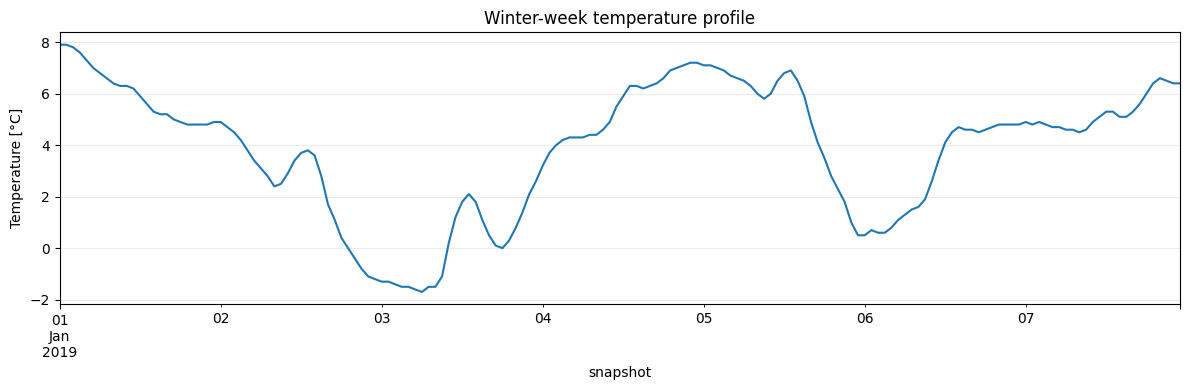

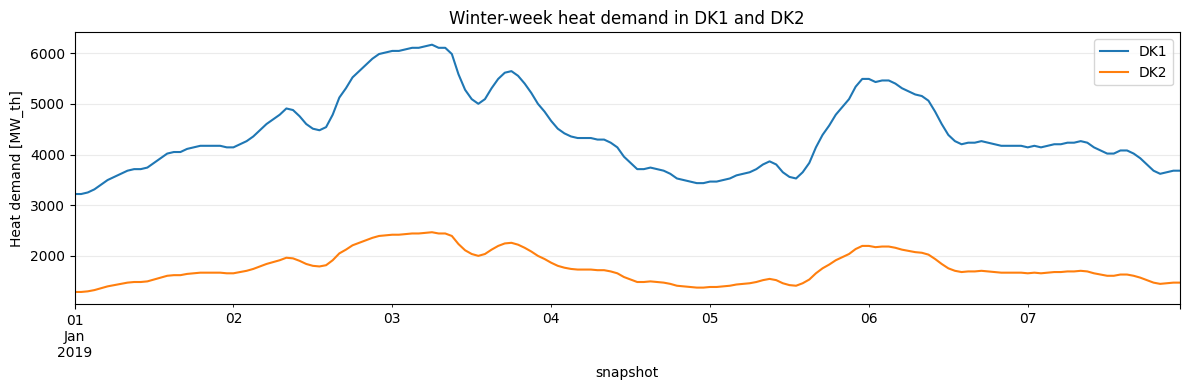

In [120]:

winter_week = n_i.snapshots[
    (pd.DatetimeIndex(n_i.snapshots).month == 1) &
    (pd.DatetimeIndex(n_i.snapshots).day <= 7)
]

fig, ax = plt.subplots(figsize=(12, 4))
temp_aligned.loc[winter_week].plot(ax=ax)
ax.set_ylabel("Temperature [°C]")
ax.set_title("Winter-week temperature profile")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
heat_demand.loc[winter_week].plot(ax=ax)
ax.set_ylabel("Heat demand [MW_th]")
ax.set_title("Winter-week heat demand in DK1 and DK2")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

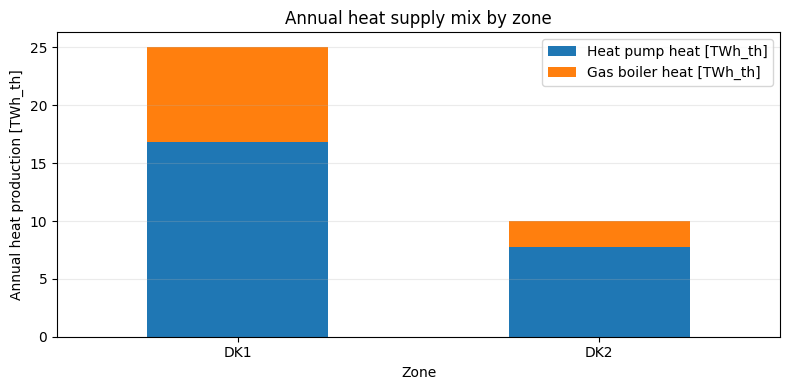

In [111]:

heat_mix = summary_i.loc[["DK1", "DK2"], [
    "Heat pump heat [TWh_th]",
    "Gas boiler heat [TWh_th]"
]]

fig, ax = plt.subplots(figsize=(8, 4))
heat_mix.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Annual heat production [TWh_th]")
ax.set_title("Annual heat supply mix by zone")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

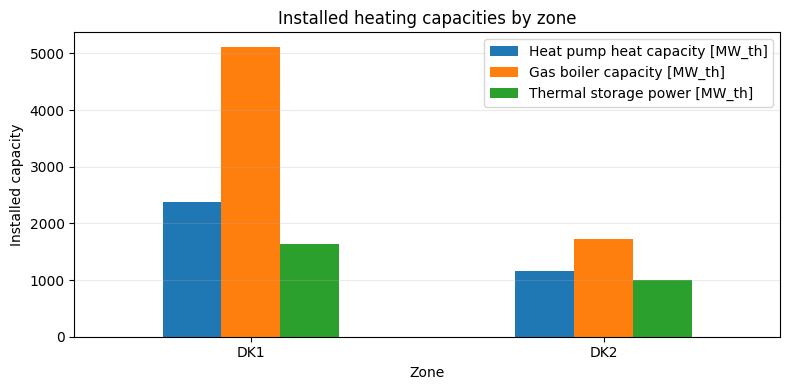

In [112]:
capacity_plot = summary_i.loc[["DK1", "DK2"], [
    "Heat pump heat capacity [MW_th]",
    "Gas boiler capacity [MW_th]",
    "Thermal storage power [MW_th]"
]]

fig, ax = plt.subplots(figsize=(8, 4))
capacity_plot.plot(kind="bar", ax=ax)
ax.set_ylabel("Installed capacity")
ax.set_title("Installed heating capacities by zone")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

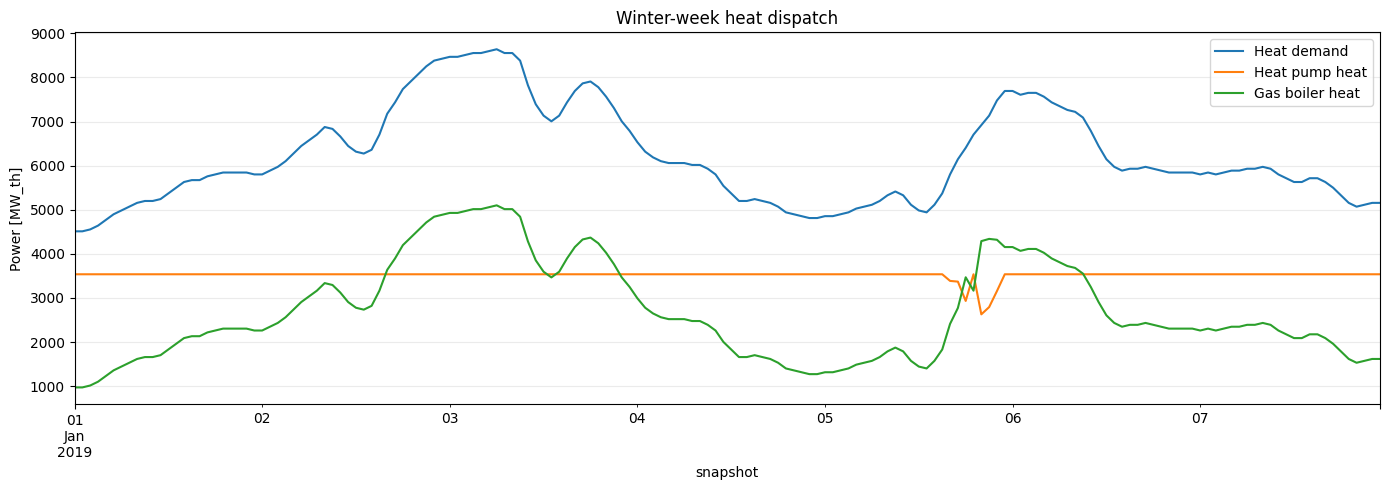

In [119]:
dispatch = pd.DataFrame(index=n_i.snapshots)

dispatch["Heat demand"] = n_i.loads_t.p[heat_loads].sum(axis=1)
dispatch["Heat pump heat"] = (-n_i.links_t.p1[heat_pumps]).sum(axis=1)
dispatch["Gas boiler heat"] = n_i.generators_t.p[gas_boilers].sum(axis=1)

dispatch_winter = dispatch.loc[winter_week]

fig, ax = plt.subplots(figsize=(14, 5))
dispatch_winter.plot(ax=ax)
ax.set_ylabel("Power [MW_th]")
ax.set_title("Winter-week heat dispatch")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Part J

In [ ]:
# Optimize conwind for increasing demand over the next couple of years 1.71 = 2030 consumption (others are just intermediate steps)
# 7530 MW is the optimal onshore wind capacity from 2025 model (n2).
# What happens when demand increases but onwind capacity is fixed at 7530 MW?

demand_scaling_factors = [1, 1.2, 1.5, 1.71]
conwind_results = {}

for scale in demand_scaling_factors:
    
    conwind.generators.at["onwind", "p_nom_min"] = 7530
    conwind.generators.at["onwind", "p_nom_max"] = 7530
    
    conwind.loads_t.p_set["demand"] = cf_year_2["demand"] * scale

    conwind.optimize(solver_name="highs")
    
    conwind_results[scale] = {
        "network": conwind,
        "dispatch": conwind.generators_t.p.copy(),
        "capacities": conwind.generators.p_nom_opt.copy()
        }

In [ ]:
# Plot capacities vs demand scaling factors for conwind results
conwind_capacity_comparison = {}

for scale, model in conwind_results.items():
    scenario_label = f"{scale:.1f}x"
    # Extract saved generator capacities from the result dictionary
    gen_capacities = model["capacities"].copy()
    
    conwind_capacity_comparison[scenario_label] = gen_capacities

# Create DataFrame for easier viewing
conwind_capacity_df = pd.DataFrame(conwind_capacity_comparison).T
conwind_capacity_df = conwind_capacity_df[["solar", "onwind", "offwind", "OCGT"]].fillna(0.0)
print("\nConwind Capacities (MW) - Onshore Wind Fixed at 7530 MW:")
display(conwind_capacity_df.round(2))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
techs_to_plot = ["solar", "onwind", "offwind", "OCGT"]

for tech in techs_to_plot:
    if tech in conwind_capacity_df.columns:
        ax.plot(
            conwind_capacity_df.index,
            conwind_capacity_df[tech],
            marker="o",
            linewidth=2,
            markersize=8,
            label=tech,
            color=colors.get(tech, "gray")
        )

ax.set_xlabel("Demand (relative to 2025)", fontsize=LABEL_SIZE)
ax.set_ylabel("Capacity [MW]", fontsize=LABEL_SIZE)
ax.set_title("Onshore wind deployment halt", fontsize=TITLE_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=LEGEND_SIZE, loc="upper left", ncol = 4)
ax.margins(x=0.02, y=0.05)
plt.tight_layout(pad=0.8)
plt.show()
